# plotting celltypes across conditions, and across compartments

In [3]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters_withraw.h5ad")
adata

AnnData object with n_obs × n_vars = 302560 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    uns: '3_subcluster', '3_subcluster_color

In [4]:
bdata = adata[adata.obs['compartment'].str.contains('orsal')].copy()

# Checking which compartment to normalise cell counts to, ventral dermis has least variability

In [10]:
import matplotlib.pyplot as plt

def plot_compartment_cellcount(adata, compartment, condition_order=None):
    """
    Plot total cell count per replicate for a given compartment,
    across conditions, split by sex.

    Parameters
    ----------
    adata : AnnData
    compartment : str
        Used only for the plot title/label — adata is assumed to already
        contain only cells from this compartment.
    condition_order : list, optional
    """

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)

    # ── Cell counts per replicate (all celltypes) ─────────────────────────────
    batch_counts = adata.obs['batch_key'].value_counts()

    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['count']     = all_batches['batch_key'].map(batch_counts).fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female',  'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = all_batches[all_batches['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'count'].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]

        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Total cells  |  {compartment}', fontsize=16)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Cell count', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles)
    plt.tight_layout()
    plt.show()

In [2]:
def rename_compartment(s):
    s_lower = s.lower()  
    if 'artilage' in s_lower:
        return 'cartilage'
    if 'orsal' in s_lower:
        if 'epidermis' in s_lower:
            return 'dorsal_epidermis'
        else:
            return 'dorsal_dermis'
    if 'entral' in s_lower:
        if 'epidermis' in s_lower:
            return 'ventral_epidermis'
        else:
            return 'ventral_dermis'
    return 'idk'

adata.obs['compartment'] = adata.obs['compartment'].apply(rename_compartment)

In [3]:
#does transcript count correlate with cell area? 
ddata = adata[adata.obs.compartment == 'dorsal_dermis']
sc.pp.calculate_qc_metrics(ddata)
ddata

View of AnnData object with n_obs × n_vars = 94477 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    uns: '3_subcluster', '3_subcluste

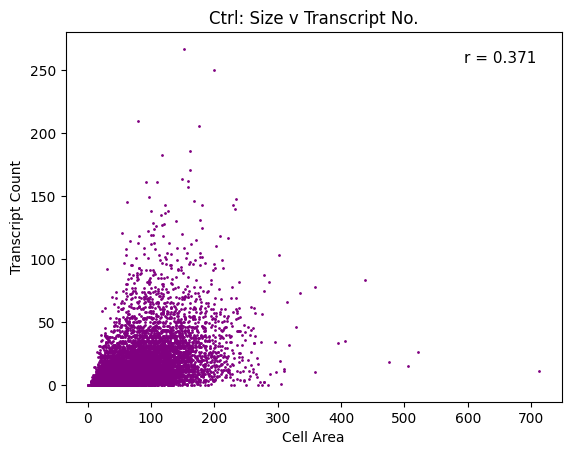

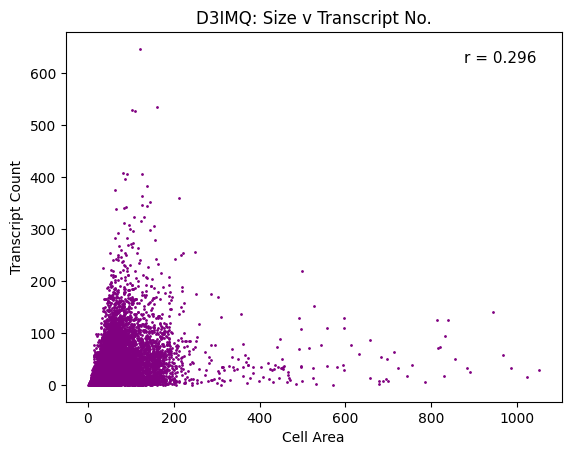

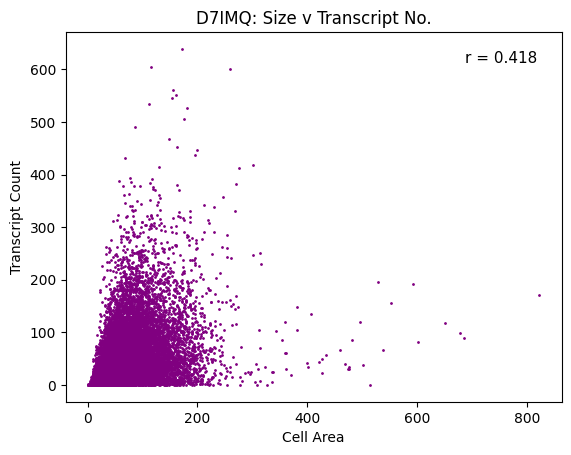

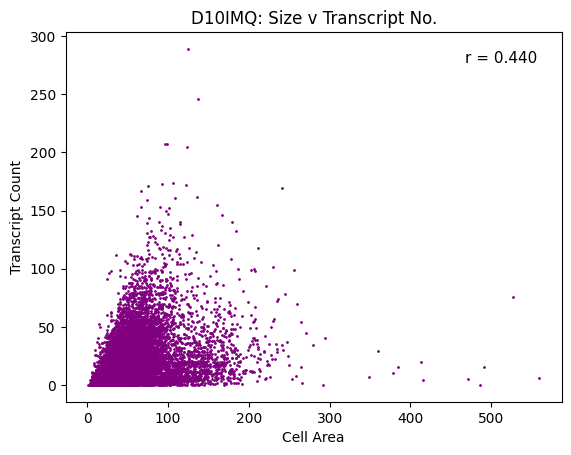

In [19]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
def plot_size_transcript_count(adata, condition):
    y = adata.obs.transcript_counts
    x = adata.obs.cell_area

    # Calculate Pearson's R
    r, p = pearsonr(x, y)

    fig, ax = plt.subplots()
    ax.scatter(x, y, s=1, color='purple')

    ax.set_title(f'{condition}: Size v Transcript No.')
    ax.set_xlabel('Cell Area')
    ax.set_ylabel('Transcript Count')

    # Display Pearson's R in top right
    ax.text(0.95, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=11)

    plt.show()

for condition in ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']:
    cdata = ddata[ddata.obs.condition == condition]
    plot_size_transcript_count(cdata, condition)

In [17]:
adata.obs.compartment.unique()

array(['ventral_epidermis', 'ventral_dermis', 'cartilage',
       'dorsal_dermis', 'dorsal_epidermis'], dtype=object)

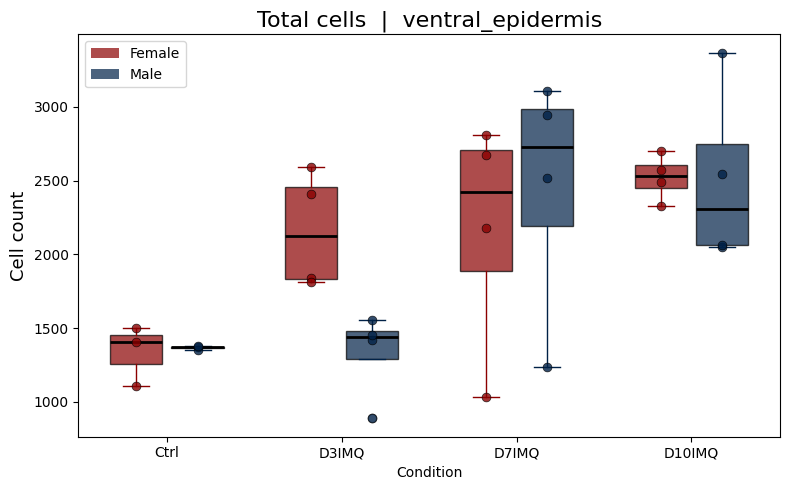

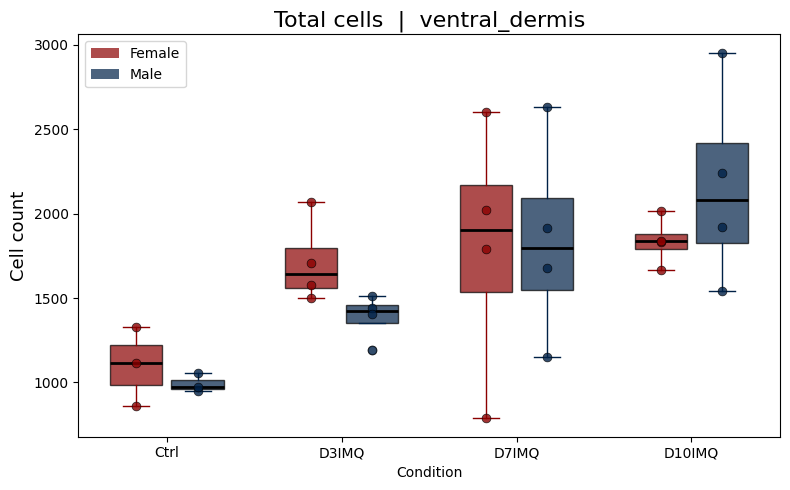

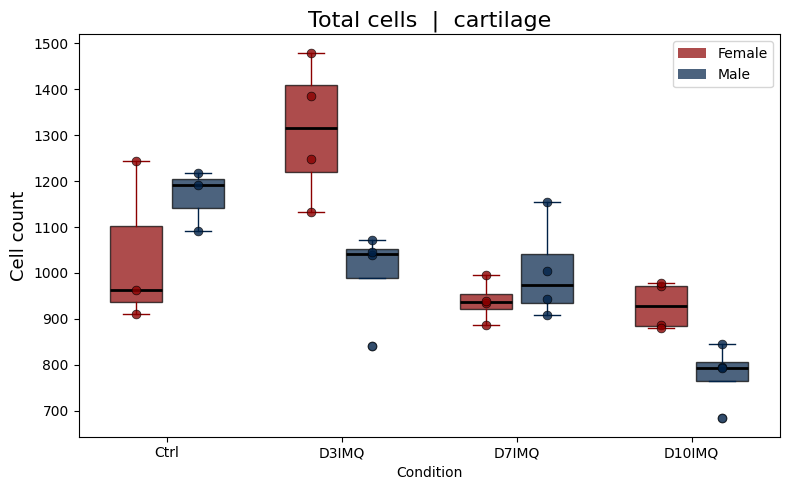

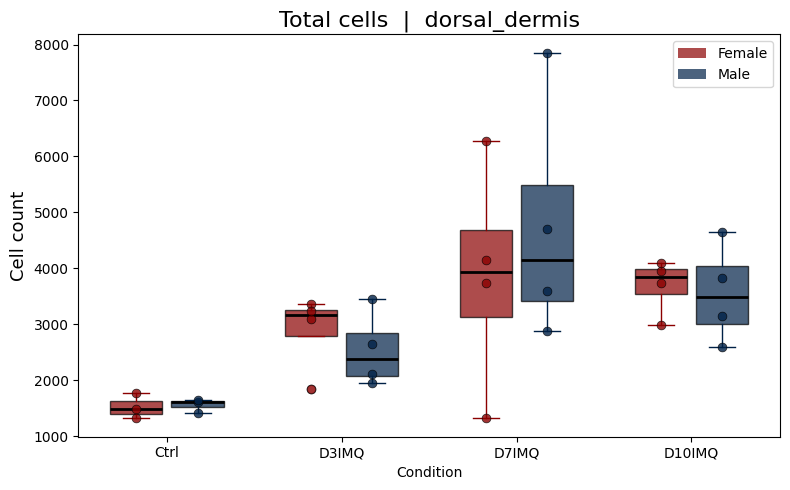

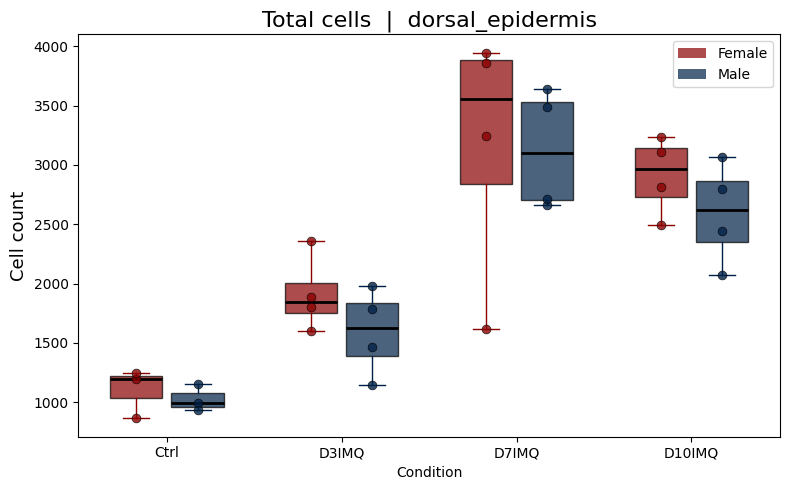

In [18]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
for compartment in ['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']:   
    bdata = adata[adata.obs['compartment'] == compartment].copy()
    plot_compartment_cellcount(adata = bdata, compartment = compartment, condition_order=condition_order) 


In [56]:
## cell density across conditions - DON'T USE adata filtered to just dorsal lolll

def plot_compartment_densities(adata, condition_order=None):

    compartments = ['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
    compartment_colors = {
        'cartilage':         '#969696',
        'ventral_epidermis': '#32C832',
        'ventral_dermis':    '#D2D2D2',
        'dorsal_dermis':     '#A032C8',
        'dorsal_epidermis':  '#DC2828',
    }

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).str.extract(r'^(.+)_[FM]\d+$')[0].unique())

    adata.obs['batch_key']   = adata.obs['batch_key'].astype(str)
    adata.obs['compartment'] = adata.obs['compartment'].astype(str)

    # ── Build per-replicate density for each compartment ─────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    for comp in compartments:
        comp_counts = (
            adata[adata.obs['compartment'] == comp]
            .obs['batch_key'].value_counts()
        )
        surface_areas = {
            batch: regions[comp]
            for batch, regions in adata.uns['region_surface_areas_um2'].items()
            if comp in regions
        }
        all_batches[f'count_{comp}']   = all_batches['batch_key'].map(comp_counts).fillna(0)
        all_batches[f'area_{comp}']    = all_batches['batch_key'].map(surface_areas)
        all_batches[f'density_{comp}'] = (all_batches[f'count_{comp}'] / all_batches[f'area_{comp}']) * 100

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions   = len(condition_order)
    n_compartments = len(compartments)
    width          = 0.8 / n_compartments
    x              = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, comp in enumerate(compartments):
            offsets     = [(xi - 0.4 + i * width + width / 2) for xi in x]
            density_col = f'density_{comp}'

            means = [sex_data.loc[sex_data['condition'] == cond, density_col].mean() for cond in condition_order]
            sems  = [sex_data.loc[sex_data['condition'] == cond, density_col].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=width * 0.9,
                color=compartment_colors[comp], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, density_col].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=compartment_colors[comp], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    axes[0].set_ylabel('Cells per 100 µm²', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=compartment_colors[c], alpha=0.85,
                       label=c.replace('_', ' '))
        for c in compartments
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.98),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Cell density by compartment', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(right=0.88)
    plt.show()

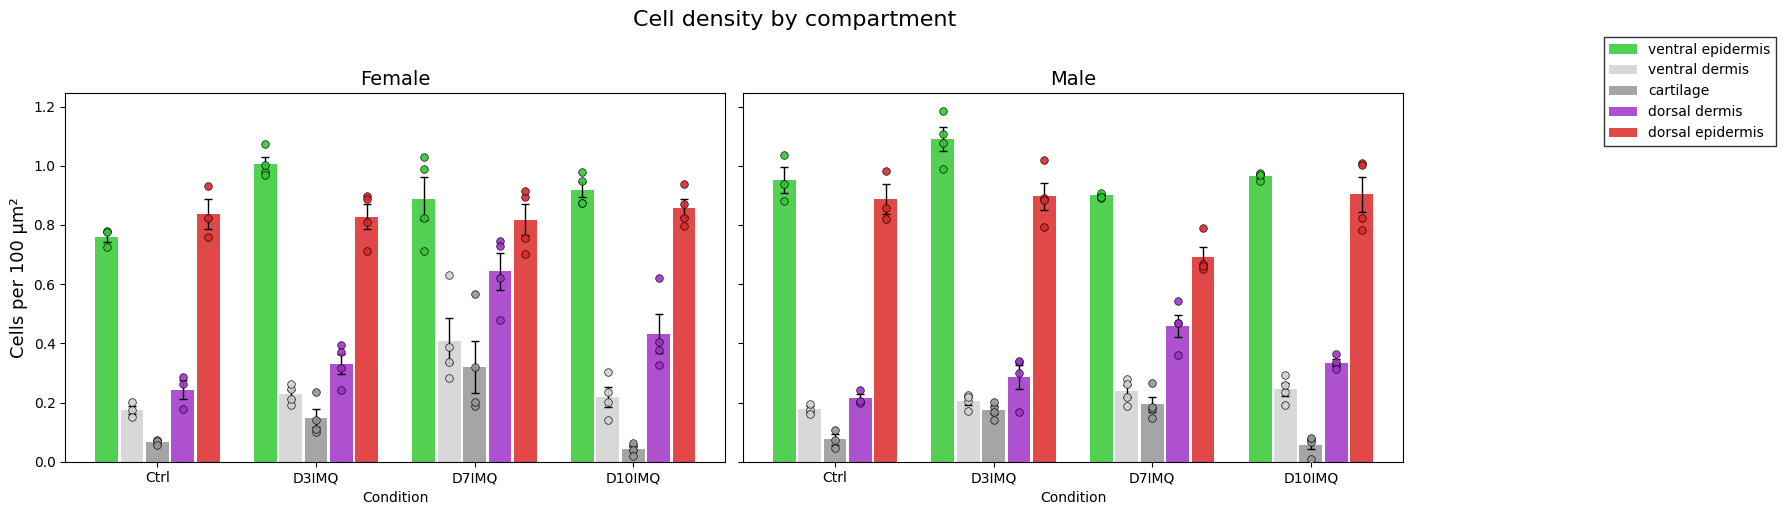

In [57]:
plot_compartment_densities(adata, condition_order=['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

# compartment thickness -- surface area

In [13]:
#plot compartment thickness over conditions. 
import pandas as pd 

#remember that these were downsampled by 0.05 and are in pixels, not microns
dermis = pd.read_excel(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\dermis_thickness_measurements.xlsx")
epidermis = pd.read_excel(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\epidermis_thickness_measurements.xlsx") 

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

def plot_tissue_thickness_combined(df, title="Compartment Thickness", metric='mean', condition_order=None, file_name = None):
    df = df.copy()

    # ==========================================
    # --- FONT SIZE CONFIGURATION ---
    # ==========================================
    TITLE_SIZE       = 25   # Down from 16
    AXIS_LABEL_SIZE  = 23   # Down from 15
    TICK_LABEL_SIZE  = 18   # Controls both X and Y axis tick marks
    LEGEND_SIZE      = 15   # Size of the legend text
    P_VAL_TOP_SIZE   = 12   # Down from 9 (M vs F)
    P_VAL_BTM_SIZE   = 9  # Down from 8 (Condition vs Control)
    # ==========================================

    spatial_scaling_factor = 0.2125 / 0.05
    numeric_cols = ['mean', 'stdDev', 'Mode', 'Min', 'Max', 'median']
    df[numeric_cols] = df[numeric_cols] * spatial_scaling_factor

    df['condition'] = df['replicate'].str.extract(r'^(.+)_[FM]\d+$')
    df['sex'] = df['replicate'].str.extract(r'_([FM])\d+$')

    if condition_order is None:
        condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
    condition_order = [c for c in condition_order if c in df['condition'].unique()]
    control = condition_order[0]
    non_controls = condition_order[1:]

    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    all_box_data = {}
    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = df[df['sex'] == sex]
        box_data = [
            sex_data.loc[sex_data['condition'] == cond, metric].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]
        all_box_data[sex] = box_data

        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    # --- M vs F t-tests (top annotations) ---
    def significance_label(p):
        if p < 0.001:   return '***'
        elif p < 0.01:  return '**'
        elif p < 0.05:  return '*'
        else:           return 'ns'

    y_range = df[metric].max() - df[metric].min()
    bracket_gap    = y_range * 0.04
    bracket_height = y_range * 0.04
    text_gap       = y_range * 0.02

    for i, cond in enumerate(condition_order):
        f_vals = all_box_data['F'][i]
        m_vals = all_box_data['M'][i]
        if len(f_vals) < 2 or len(m_vals) < 2:
            continue

        _, p_val = stats.ttest_ind(f_vals, m_vals, equal_var=False)
        label = significance_label(p_val)

        cond_max = max(f_vals.max(), m_vals.max())
        y_base = cond_max + bracket_gap
        y_tip  = y_base + bracket_height

        x_left, x_right = i - width / 2, i + width / 2
        ax.plot([x_left,  x_left],  [y_base, y_tip], color='black', linewidth=1)
        ax.plot([x_left,  x_right], [y_tip,  y_tip], color='black', linewidth=1)
        ax.plot([x_right, x_right], [y_tip,  y_base], color='black', linewidth=1)

        annotation = f'{label}\np={p_val:.3f}'
        ax.text(i, y_tip + text_gap, annotation,
                ha='center', va='bottom', fontsize=P_VAL_TOP_SIZE, color='black')

    # --- Within-sex condition vs control t-tests with BH correction (bottom annotations) ---
    bottom_gap      = y_range * 0.04   
    row_height      = y_range * 0.08   

    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        ctrl_idx  = condition_order.index(control)
        ctrl_vals = all_box_data[sex][ctrl_idx]

        raw_p = []
        valid_indices = []
        for cond in non_controls:
            ci = condition_order.index(cond)
            cond_vals = all_box_data[sex][ci]
            if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                _, p = stats.ttest_ind(ctrl_vals, cond_vals, equal_var=False)
                raw_p.append(p)
                valid_indices.append(ci)

        if not raw_p:
            continue

        _, corrected_p, _, _ = multipletests(raw_p, method='fdr_bh')

        row = 0 if sex == 'F' else 1
        sex_min = min(vals.min() for vals in all_box_data[sex] if len(vals) > 0)
        y_row = sex_min - bottom_gap - row * row_height

        for ci, p_corr in zip(valid_indices, corrected_p):
            label = significance_label(p_corr)
            x_pos = ci + offset
            annotation = f'{label}\np={p_corr:.3f}'
            ax.text(x_pos, y_row, annotation,
                    ha='center', va='top', fontsize=P_VAL_BTM_SIZE,
                    color=sex_colors[sex])

    # Labels and layout
    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order, fontsize=TICK_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE) # Added y-tick sizing
    
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xlabel('Condition', fontsize=AXIS_LABEL_SIZE)

    metric_label = 'Mean' if metric == 'mean' else 'Median'
    ax.set_ylabel(f'{metric_label} Thickness (µm)', fontsize=AXIS_LABEL_SIZE)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles, fontsize=LEGEND_SIZE) # Updated legend size

    # Padding for top and bottom annotations
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - y_range * 0.25, y_max * 1.15)

    if file_name:
        plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{file_name}", dpi = 500, bbox_inches = 'tight')

    plt.tight_layout()
    plt.show()

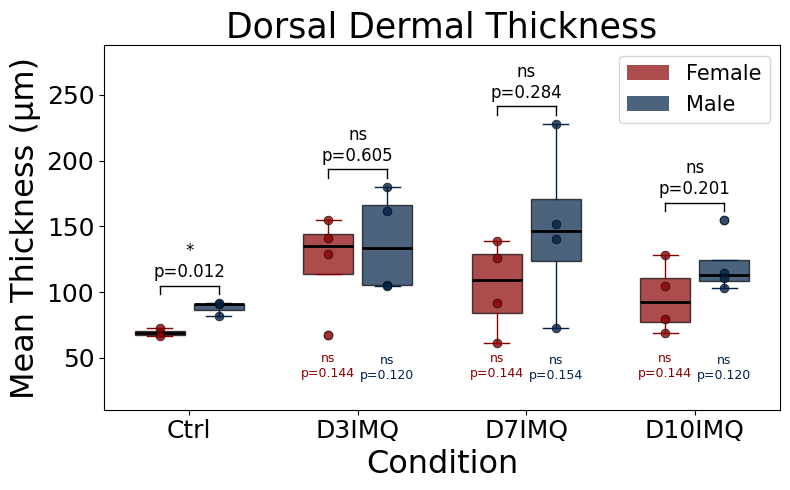

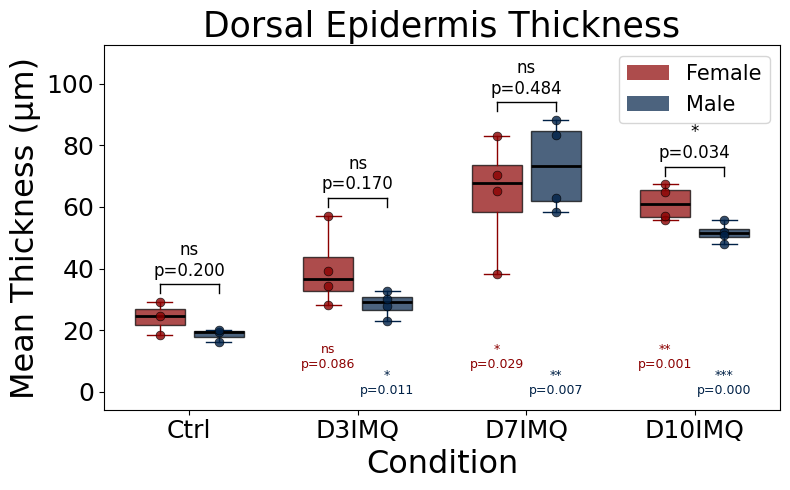

In [26]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']


plot_tissue_thickness_combined(dermis, title="Dorsal Dermal Thickness", metric='mean', condition_order=condition_order, file_name = 'dermal_thickness.png')
plot_tissue_thickness_combined(epidermis, title="Dorsal Epidermis Thickness", metric='mean', condition_order=condition_order, file_name = 'epidermal_thickness.png')

In [32]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FEMALE_COLOR = '#8B0000'
MALE_COLOR   = '#002147'
CONDITION_ORDER = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

def plot_surface_area_by_condition(condition_shapes, compartment, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # ==========================================
    # --- FONT SIZE CONFIGURATION ---
    # ==========================================
    TITLE_SIZE       = 25   # Down from 16
    AXIS_LABEL_SIZE  = 23   # Down from 15
    TICK_LABEL_SIZE  = 18   # Controls both X and Y axis tick marks
    LEGEND_SIZE      = 15   # Size of the legend text
    P_VAL_TOP_SIZE   = 12   # Down from 9 (M vs F)
    P_VAL_BTM_SIZE   = 9  # Down from 8 (Condition vs Control)
    # ==========================================

    female_data = {c: [] for c in CONDITION_ORDER}
    male_data   = {c: [] for c in CONDITION_ORDER}

    for key, shapes in condition_shapes.items():
        if compartment not in shapes:
            continue
        parts = key.split('_')
        condition = parts[0] if len(parts) == 3 else '_'.join(parts[:-1])
        rep = parts[-1]
        if condition not in CONDITION_ORDER:
            continue
        if rep.startswith('F'):
            female_data[condition].append(shapes[compartment] / 1e6)
        elif rep.startswith('M'):
            male_data[condition].append(shapes[compartment] / 1e6)

    positions_f = np.arange(len(CONDITION_ORDER)) - 0.2
    positions_m = np.arange(len(CONDITION_ORDER)) + 0.2

    def styled_boxplot(data_list, positions, color):
        ax.boxplot(
            data_list,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops    =dict(facecolor=color, alpha=0.7, color="#000204", linewidth=1.5),
            medianprops =dict(color='black', linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5),
            capprops    =dict(color=color, linewidth=1.5),
            flierprops  =dict(marker='o', markerfacecolor=color, markeredgecolor=color,
                              markersize=5, alpha=0.6),
        )
        for i, vals in enumerate(data_list):
            jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), positions[i]) + jitter, vals,
                       color=color, s=30, zorder=3, alpha=0.8)

    styled_boxplot([female_data[c] for c in CONDITION_ORDER], positions_f, FEMALE_COLOR)
    styled_boxplot([male_data[c]   for c in CONDITION_ORDER], positions_m, MALE_COLOR)

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontsize=TICK_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE) # Standardized Y-axis tick sizes
    
    ax.set_ylabel('Surface area (mm²)', fontsize=AXIS_LABEL_SIZE)
    ax.set_title(f'{compartment.replace("_", " ").title()} surface area', fontsize=TITLE_SIZE)

    # ── helpers ──────────────────────────────────────────────────────────────
    def significance_label(p):
        if p < 0.001: return '***'
        elif p < 0.01:  return '**'
        elif p < 0.05:  return '*'
        else:           return 'ns'

    def format_pvalue(p):
        return f'p = {p:.3f} {significance_label(p)}'

    # ── M vs F brackets (top) ────────────────────────────────────────────────
    all_vals = [v for d in (female_data, male_data)
                  for vals in d.values() for v in vals]
    y_range = max(all_vals) - min(all_vals)

    def draw_brace(x_f, x_m, y_top, p):
        label = format_pvalue(p)
        tick_h = y_range * 0.015
        ax.plot([x_f, x_f, x_m, x_m],
                [y_top, y_top + tick_h, y_top + tick_h, y_top],
                lw=1.2, color='black')
        ax.text((x_f + x_m) / 2, y_top + tick_h * 1.3, label,
                ha='center', va='bottom', fontsize=P_VAL_TOP_SIZE,
                color='black' if p < 0.05 else '#888888')

    y_min_data = min(all_vals)
    y_max_data = max(all_vals)

    for i, condition in enumerate(CONDITION_ORDER):
        f_vals = female_data[condition]
        m_vals = male_data[condition]
        if len(f_vals) < 2 or len(m_vals) < 2:
            continue
        _, p = stats.ttest_ind(f_vals, m_vals)
        brace_y = max(max(f_vals), max(m_vals)) + y_range * 0.04
        draw_brace(positions_f[i], positions_m[i], brace_y, p)

    # ── Within-sex condition vs control, BH-corrected (bottom) ───────────────
    control       = CONDITION_ORDER[0]
    non_controls  = CONDITION_ORDER[1:]
    bottom_gap    = y_range * 0.04   
    row_height    = y_range * 0.10   

    sex_data_map = {'F': (female_data, positions_f, FEMALE_COLOR),
                    'M': (male_data,   positions_m, MALE_COLOR)}

    for row_idx, (sex, (sex_data, positions, color)) in enumerate(sex_data_map.items()):
        ctrl_vals = sex_data[control]
        raw_p, valid_cond_indices = [], []

        for cond in non_controls:
            ci = CONDITION_ORDER.index(cond)
            cond_vals = sex_data[cond]
            if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                _, p = stats.ttest_ind(ctrl_vals, cond_vals, equal_var=False)
                raw_p.append(p)
                valid_cond_indices.append(ci)

        if not raw_p:
            continue

        _, corrected_p, _, _ = multipletests(raw_p, method='fdr_bh')

        sex_min = min(v for vals in sex_data.values() for v in vals) if any(sex_data.values()) else y_min_data
        y_row = sex_min - bottom_gap - row_idx * row_height

        for ci, p_corr in zip(valid_cond_indices, corrected_p):
            label = significance_label(p_corr)
            annotation = f'{label}\np={p_corr:.3f}'
            ax.text(positions[ci], y_row, annotation,
                    ha='center', va='top', fontsize=P_VAL_BTM_SIZE, color=color)

    # ── axis limits ──────────────────────────────────────────────────────────
    ax.set_ylim(y_min_data - y_range * 0.30, y_max_data + y_range * 0.25)

    legend_handles = [
        mpatches.Patch(facecolor=FEMALE_COLOR, edgecolor=FEMALE_COLOR, label='Female'),
        mpatches.Patch(facecolor=MALE_COLOR,   edgecolor=MALE_COLOR,   label='Male'),
    ]
    ax.legend(handles=legend_handles, frameon=True, edgecolor='black', fontsize=LEGEND_SIZE)
    plt.tight_layout()
    plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{title}.png", bbox_inches = 'tight', dpi = 500)

    return ax

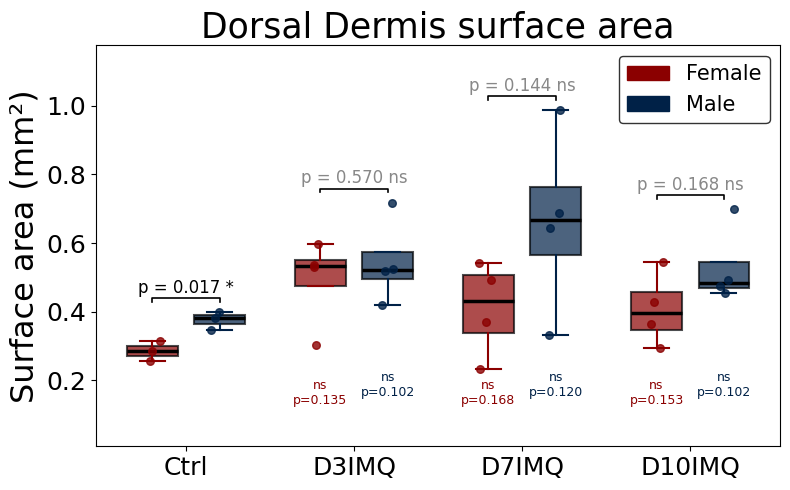

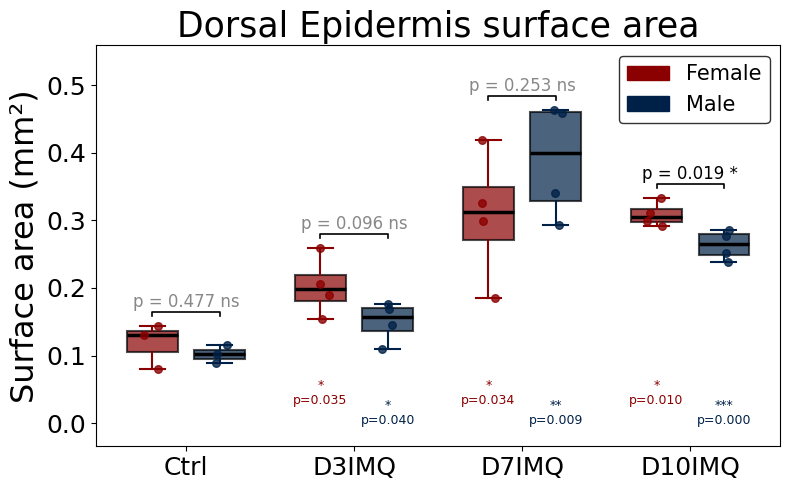

In [33]:
condition_shapes = adata.uns['region_surface_areas_um2']

for compartment in ['dorsal_dermis', 'dorsal_epidermis']:
    title = f'{compartment} surface area'
    plot_surface_area_by_condition(condition_shapes, compartment, title = title)

# Normalising using surface area (cell density)

In [4]:
import scanpy as sc 
adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters_withraw.h5ad")
adata = adata[adata.obs.compartment.str.contains('orsal')]
adata

View of AnnData object with n_obs × n_vars = 162096 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    uns: '3_subcluster', '3_subclust

## celltype - compartment - single plots

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_cell_density(adata, celltype, compartment, condition_order=None):
    """
    Plot cell density (cells per µm²) for a given celltype, normalised
    to the surface area of the specified compartment.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing dorsal cells.
    celltype : str
        Value in adata.obs['celltype_assignments'] to plot.
    compartment : str
        Key in adata.uns['region_surface_areas_um2'][replicate] to use
        as the area denominator (e.g. 'dorsal_dermis', 'dorsal_epidermis').
    condition_order : list, optional
        Order of conditions on x-axis. Defaults to sorted unique conditions.
    """

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    # ── Surface area lookup ───────────────────────────────────────────────────
    surface_areas = {
        batch: regions[compartment]
        for batch, regions in adata.uns['region_surface_areas_um2'].items()
        if compartment in regions
    }

    # ── Cell counts per replicate ─────────────────────────────────────────────
    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    cluster_data = adata[adata.obs['celltype_assignments'] == celltype]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    # ── Build per-replicate dataframe ─────────────────────────────────────────
    all_batches = (
        adata.obs[['batch_key']]
        .drop_duplicates()
        .copy()
        .astype(str)
    )
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['count']     = all_batches['batch_key'].map(batch_counts).fillna(0)
    all_batches['area_um2']  = all_batches['batch_key'].map(surface_areas)
    all_batches['density']   = all_batches['count'] / all_batches['area_um2'] *100

    missing = all_batches['area_um2'].isna().sum()
    if missing:
        print(f"Warning: {missing} replicate(s) have no area data for '{compartment}' and will be dropped.")
        all_batches = all_batches.dropna(subset=['area_um2'])

    # ── Plot ──────────────────────────────────────────────────────────────────
    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female',  'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = all_batches[all_batches['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'density'].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]

        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'{celltype.replace("_", " ")}  |  normalised to {compartment.replace("_", " ")}', fontsize=16)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Cells per 100 µm²', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles)
    plt.tight_layout()
    plt.show()

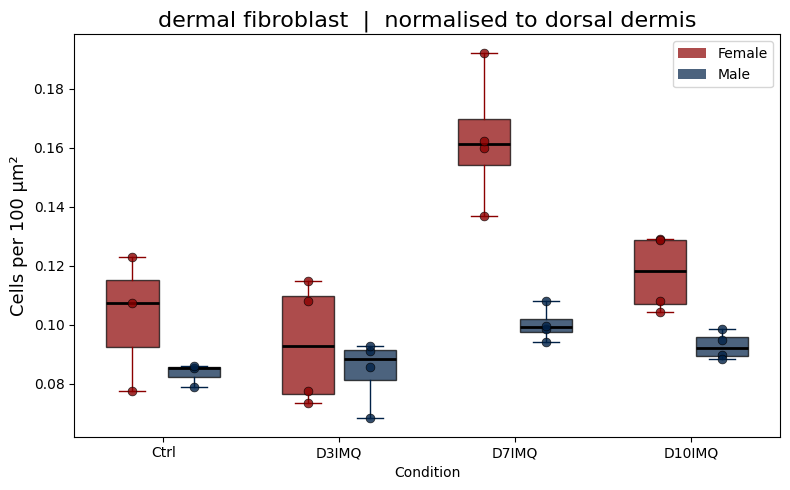

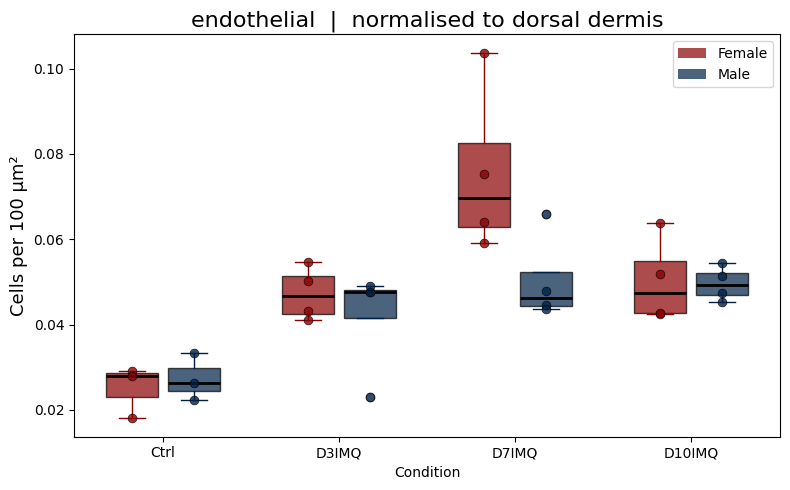

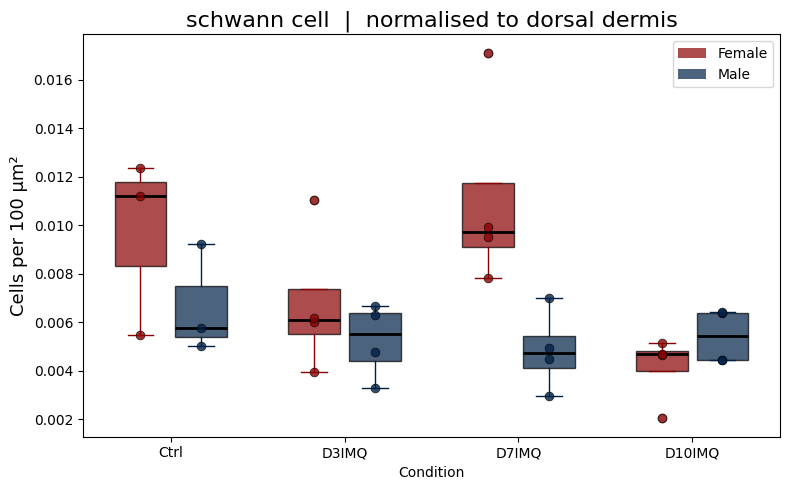

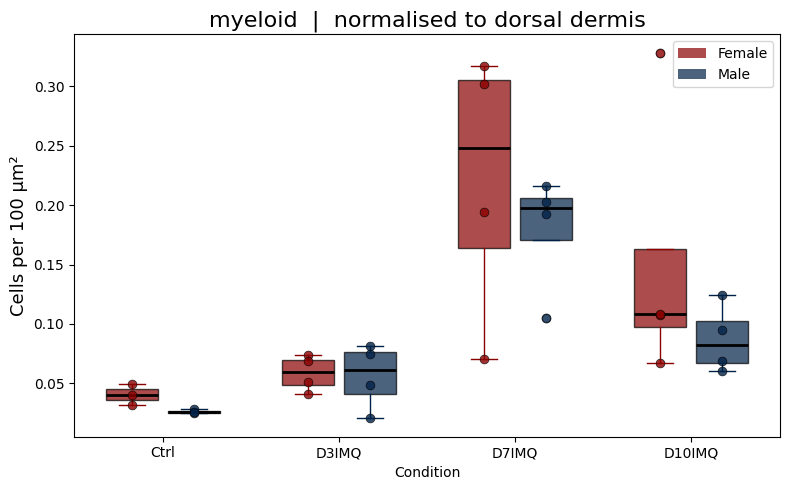

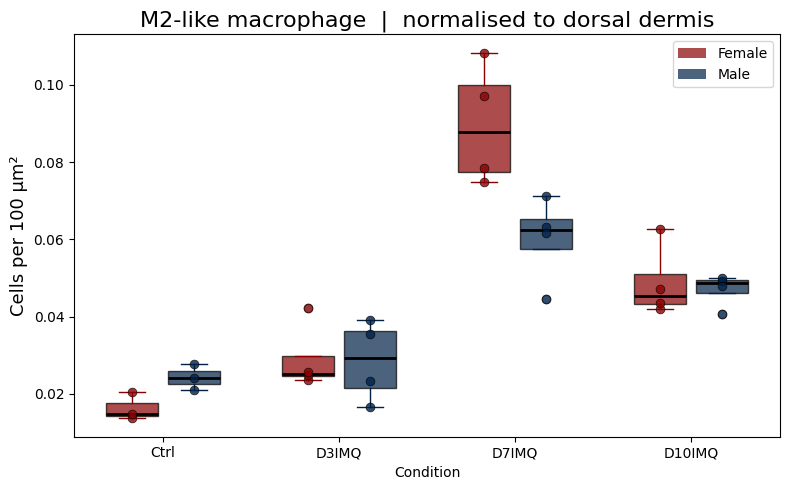

In [18]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

for celltype in ['dermal_fibroblast', 'endothelial', 'schwann_cell', 'myeloid', 'M2-like_macrophage']:
    plot_cell_density(adata, celltype, 'dorsal_dermis', condition_order=condition_order)

## multiple cell types on one graph - proportions

In [5]:
#STATS VERSION
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

def plot_grouped_proportions(adata, celltypes, compartment, condition_order=None, file_name = None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors = adata.uns['celltype_assignments_colors']
    color_map = dict(zip(categories, colors))
    adata = adata[adata.obs['compartment'] == compartment]

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    # ── Build per-replicate proportions for each celltype ─────────────────────
    batch_totals = adata.obs['batch_key'].value_counts()

    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)
        all_batches[ct] = all_batches[ct] / all_batches['batch_key'].map(batch_totals) * 100

    # ── Compute BH-corrected p-values per sex ─────────────────────────────────
    # For each sex, run one t-test per (celltype, non-ctrl condition) pair,
    # then apply BH correction across all tests within that sex.
    ctrl = condition_order[0]
    non_ctrl = condition_order[1:]

    def compute_significance(sex_data):
        sig = {}

        for ct in celltypes:
            ctrl_vals = sex_data.loc[sex_data['condition'] == ctrl, ct].values
            raw_pvals = []

            for cond in non_ctrl:
                cond_vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                    _, p = stats.ttest_ind(np.log(ctrl_vals + 1e-9), np.log(cond_vals + 1e-9))
                else:
                    p = 1.0
                raw_pvals.append(p)

            # BH correction across the 3 tests for this celltype only
            _, corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')

            for cond, p_corr in zip(non_ctrl, corrected):
                if p_corr < 0.001:
                    sig[(ct, cond)] = '***'
                elif p_corr < 0.01:
                    sig[(ct, cond)] = '**'
                elif p_corr < 0.05:
                    sig[(ct, cond)] = '*'

        return sig

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]
        sig = compute_significance(sex_data)

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

                # Place star just above the error bar cap if significant
                if (ct, cond) in sig:
                    star_y = means[j] + sems[j] + (ax.get_ylim()[1] * 0.02)
                    ax.text(
                        offsets[j], star_y, sig[(ct, cond)],
                        ha='center', va='bottom', fontsize=10,
                        color='black', fontweight='bold'
                    )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=20)
        ax.set_xlabel('Condition', fontsize=18)

    axes[0].set_ylabel(f'% of total {compartment.replace("_", " ")} cells', fontsize=15)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle(f'Cell type proportions  |  {compartment.replace("_", " ")}', fontsize=25, y=1.02)

    plt.tight_layout(rect = [0,0,1,0.97])
    #plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{file_name}", dpi = 500, bbox_inches = 'tight')
    plt.show()


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_38204\3300781937.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


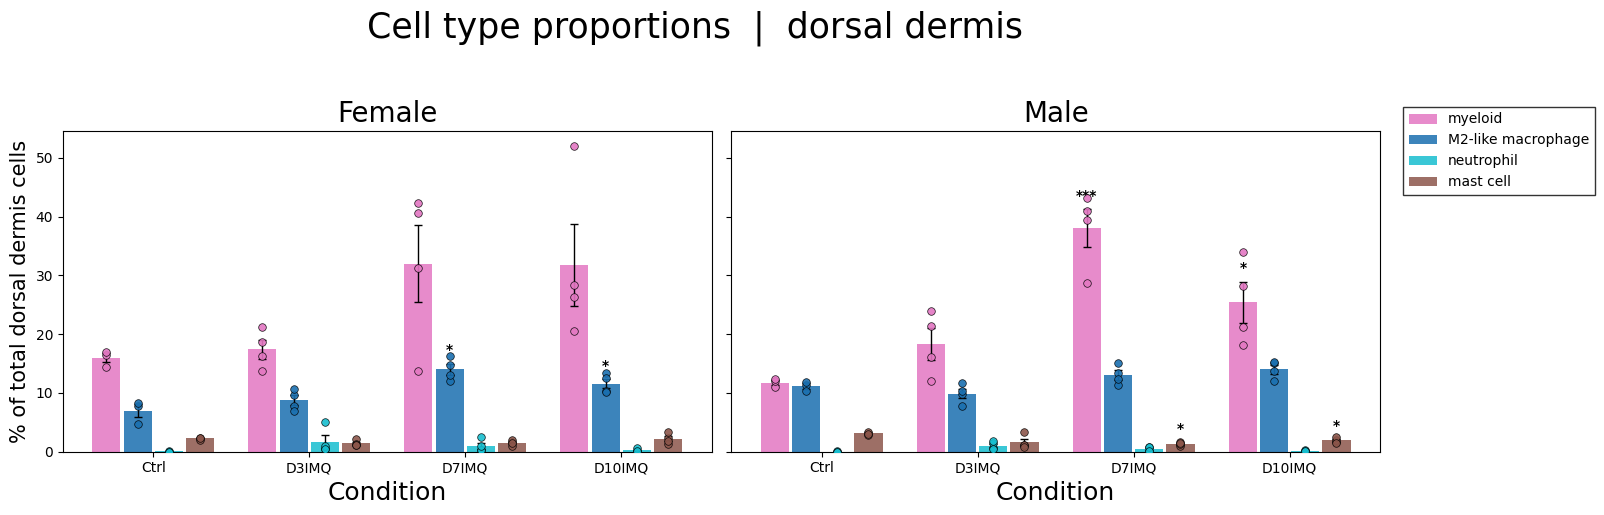

In [6]:
celltypes = ['myeloid', 'M2-like_macrophage', 'neutrophil', 'mast_cell']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment='dorsal_dermis', condition_order=condition_order, file_name = "mast_immune_dermal_proportions.png")

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\3137635795.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


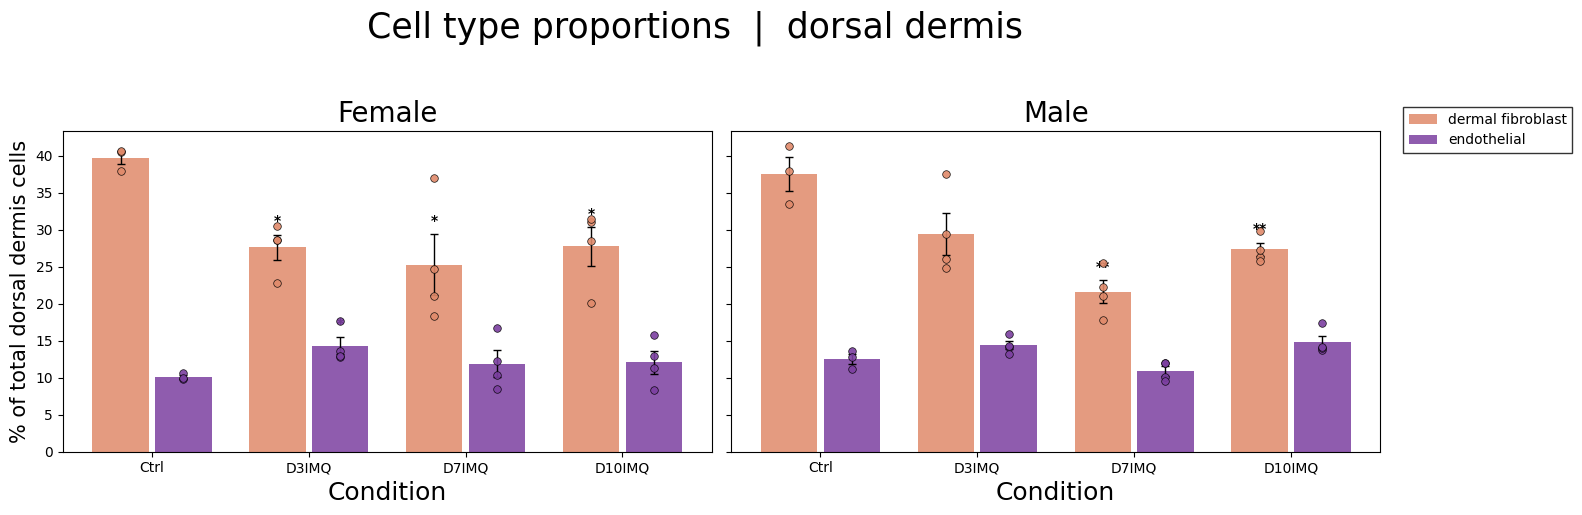

In [43]:
celltypes = ['dermal_fibroblast', 'endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)

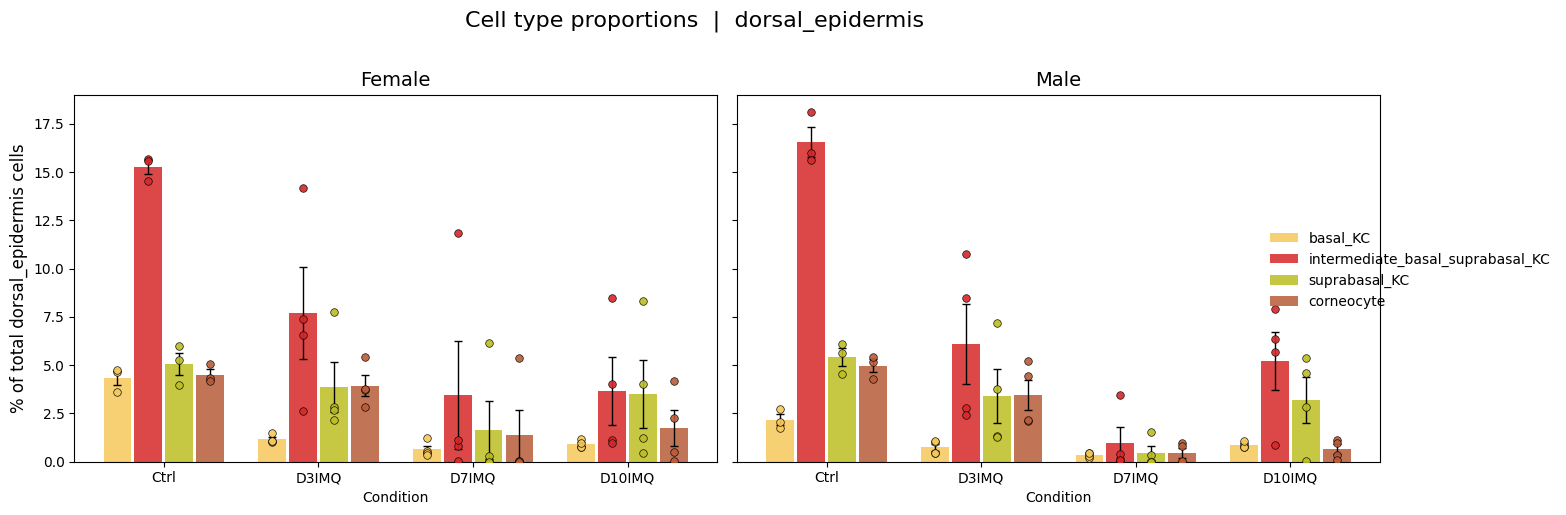

In [27]:
celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment, condition_order=condition_order)

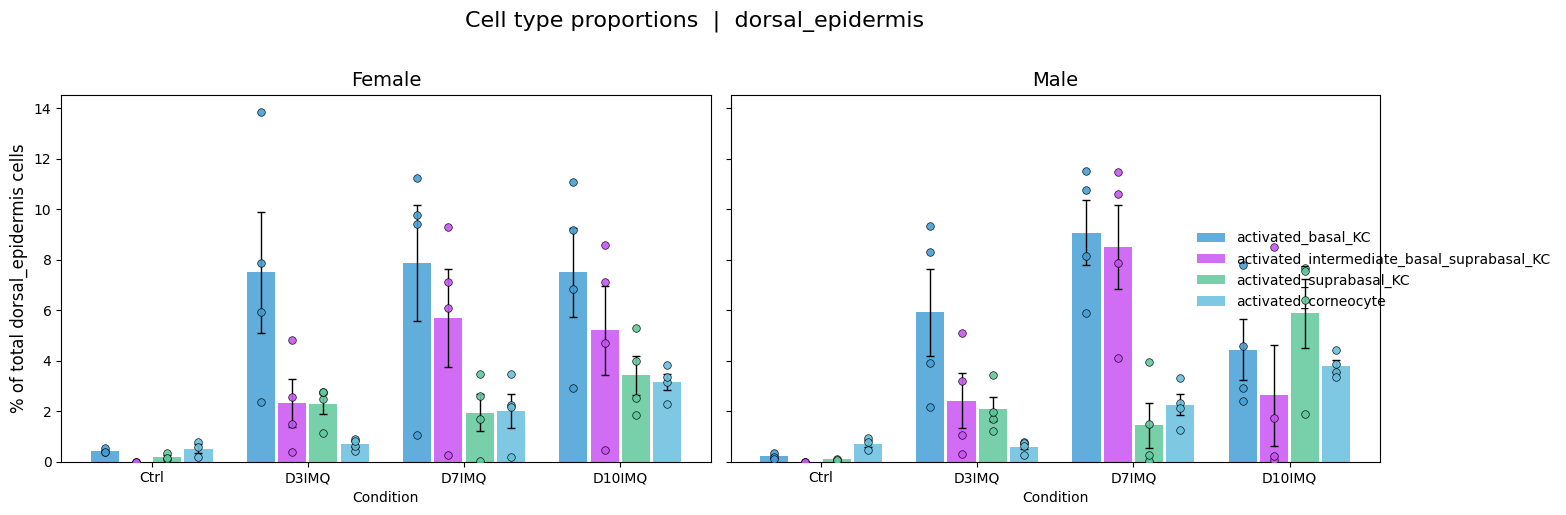

: 

In [ ]:
celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment, condition_order=condition_order)

## multiple cell types on one graph - density (Surface area normalisation)

In [37]:
#STATS AND SAVE VERSION
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

def plot_grouped_densities(adata, celltypes, compartment, condition_order=None, file_name=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    adata = adata[adata.obs['compartment'] == compartment]

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments']  = adata.obs['celltype_assignments'].astype(str)

    # ── Surface area lookup ───────────────────────────────────────────────────
    surface_areas = {
        batch: regions[compartment]
        for batch, regions in adata.uns['region_surface_areas_um2'].items()
        if compartment in regions
    }

    # ── Build per-replicate densities for each celltype ───────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['area_um2']  = all_batches['batch_key'].map(surface_areas)

    missing = all_batches['area_um2'].isna().sum()
    if missing:
        print(f"Warning: {missing} replicate(s) missing area data for '{compartment}' and will be dropped.")
        all_batches = all_batches.dropna(subset=['area_um2'])

    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)
        all_batches[ct] = (all_batches[ct] / all_batches['area_um2']) * 100

    # ── Significance testing ──────────────────────────────────────────────────
    ctrl     = condition_order[0]
    non_ctrl = condition_order[1:]

    def compute_significance(sex_data):
        sig = {}
        for ct in celltypes:
            ctrl_vals = sex_data.loc[sex_data['condition'] == ctrl, ct].values
            raw_pvals = []
            for cond in non_ctrl:
                cond_vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                    _, p = stats.ttest_ind(np.log(ctrl_vals + 1e-9), np.log(cond_vals + 1e-9))
                else:
                    p = 1.0
                raw_pvals.append(p)

            _, corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')

            for cond, p_corr in zip(non_ctrl, corrected):
                if p_corr < 0.001:
                    sig[(ct, cond)] = '***'
                elif p_corr < 0.01:
                    sig[(ct, cond)] = '**'
                elif p_corr < 0.05:
                    sig[(ct, cond)] = '*'
        return sig

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]
        sig      = compute_significance(sex_data)

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

                if (ct, cond) in sig:
                    star_y = means[j] + sems[j] + (ax.get_ylim()[1] * 0.02)
                    ax.text(
                        offsets[j], star_y, sig[(ct, cond)],
                        ha='center', va='bottom', fontsize=10,
                        color='black', fontweight='bold'
                    )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order, fontsize=13)
        ax.set_title(sex_labels[sex], fontsize=20)
        ax.set_xlabel('Condition', fontsize=18)

    axes[0].set_ylabel(f'Cells per 100 µm²  |  {compartment.replace("_", " ")}', fontsize=15)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle(f'Cell type densities  |  {compartment.replace("_", " ")}', fontsize=25, y=1.02)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{file_name}", dpi=500, bbox_inches='tight')
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\1898141668.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


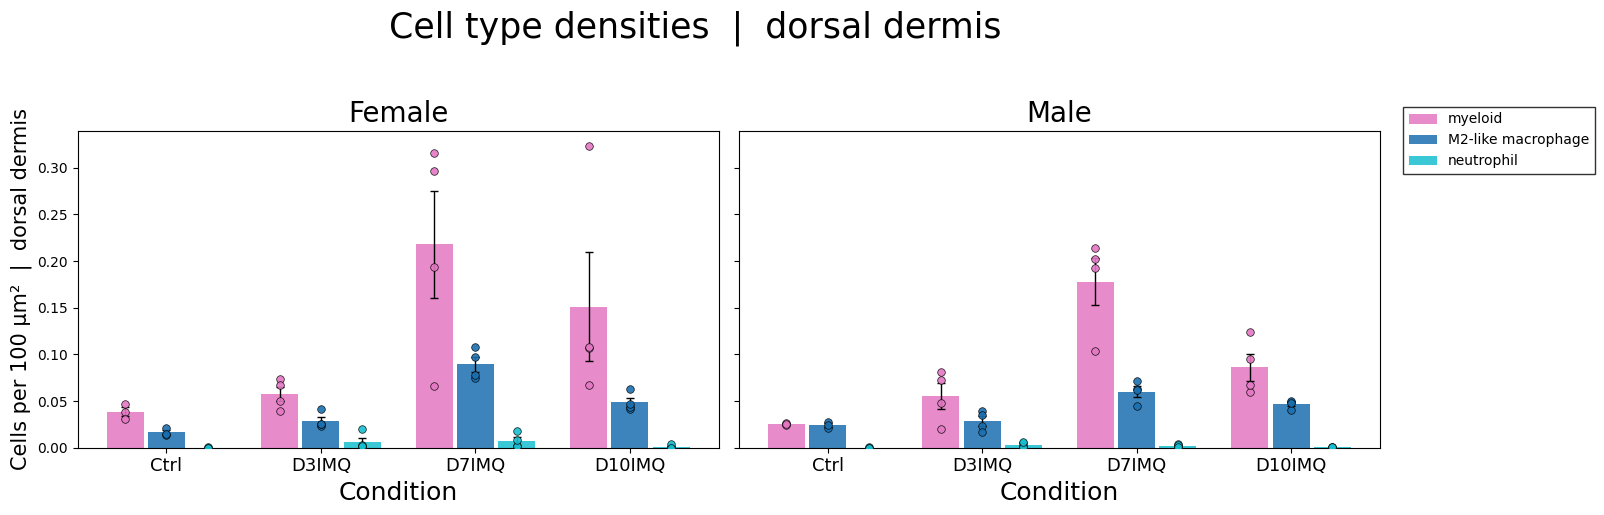

In [35]:
celltypes = ['myeloid', 'M2-like_macrophage', 'neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order, file_name = 'non-activated_KCs_density.png')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


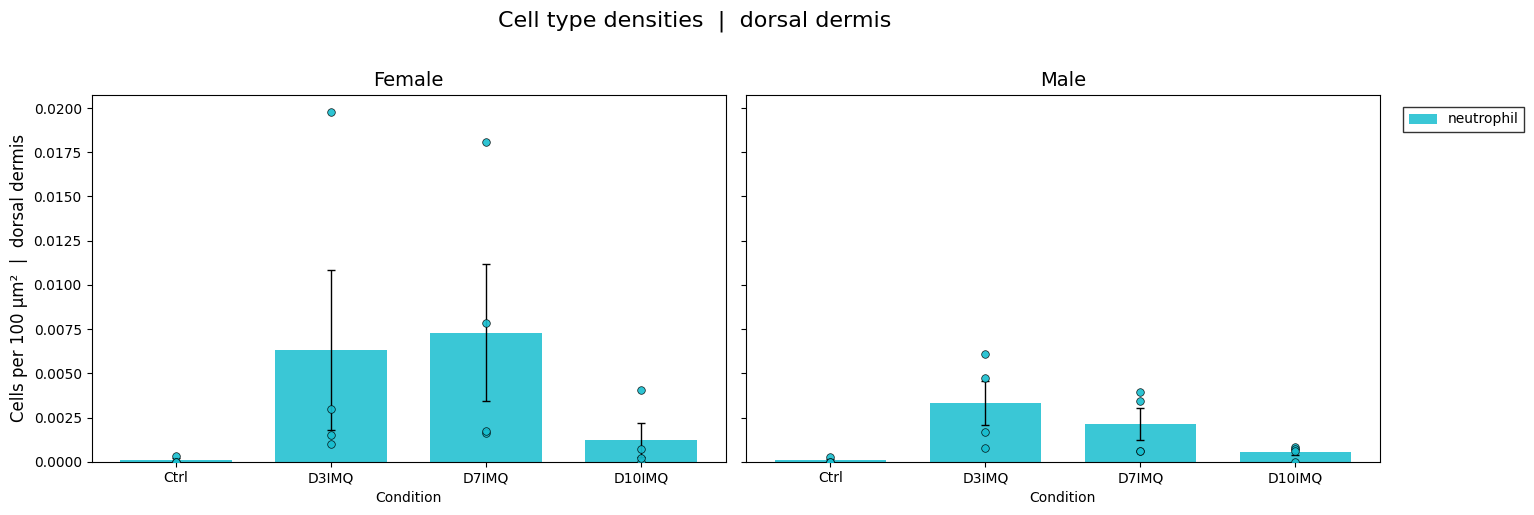

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


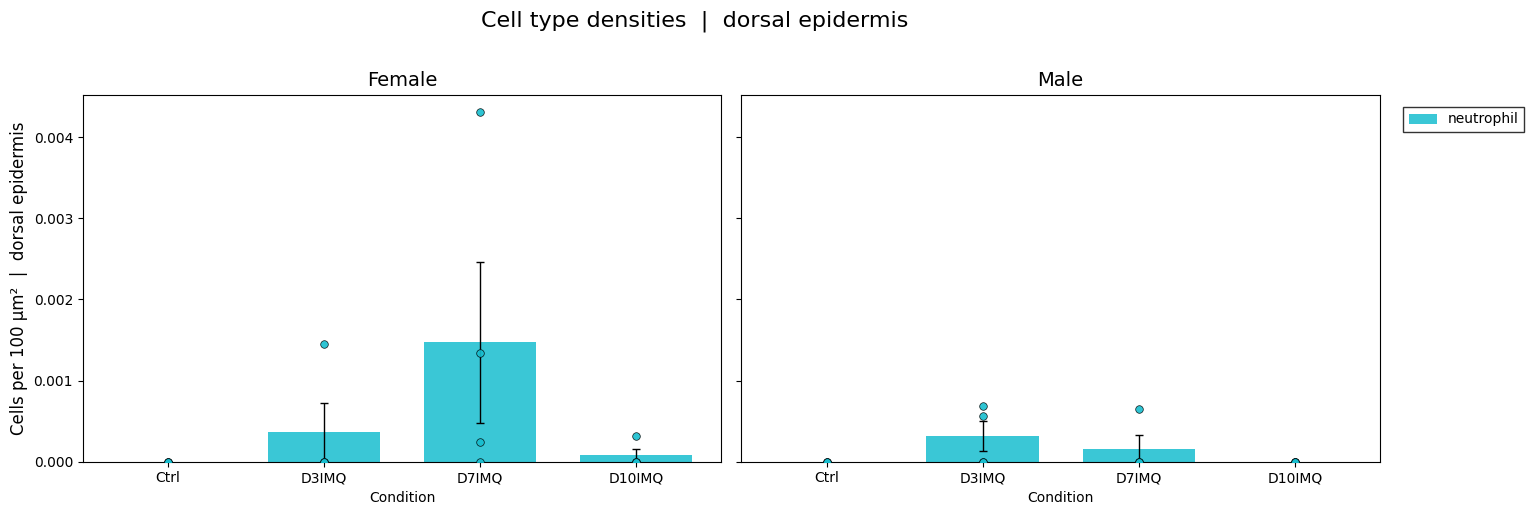

In [47]:
celltypes = ['neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)
plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\3962423803.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


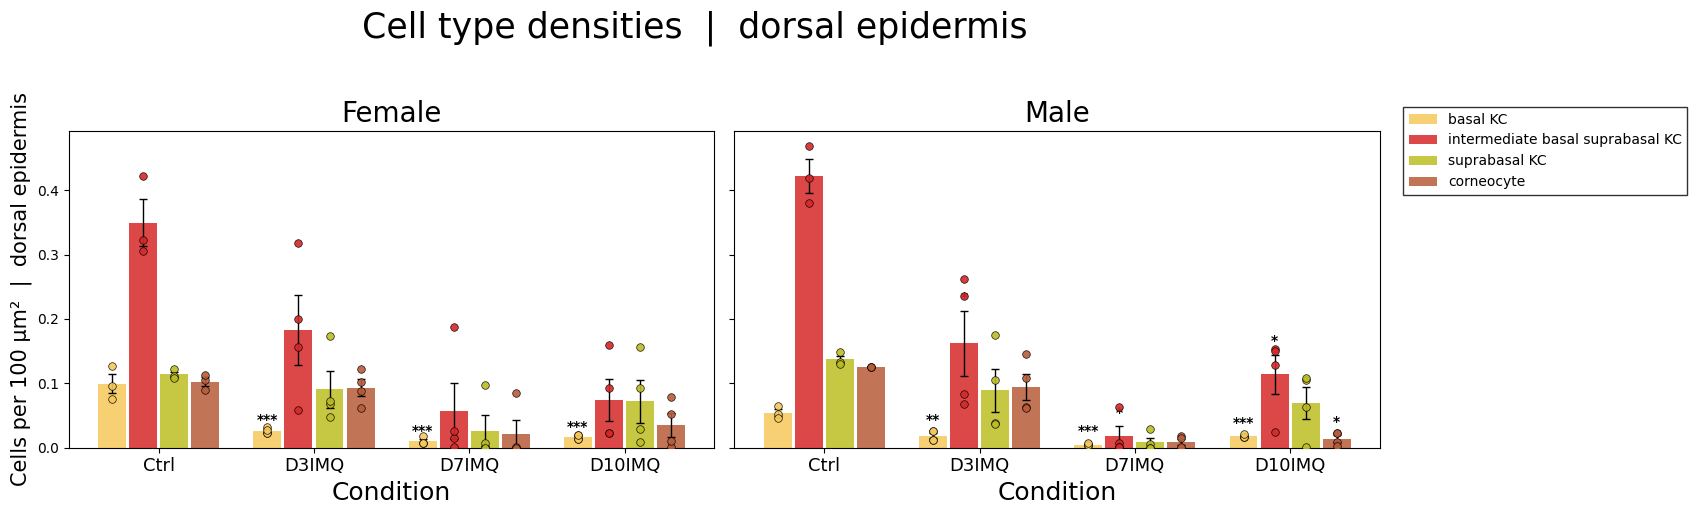

In [38]:
celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order, file_name = 'non-activated_KCs_density.png')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\3962423803.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


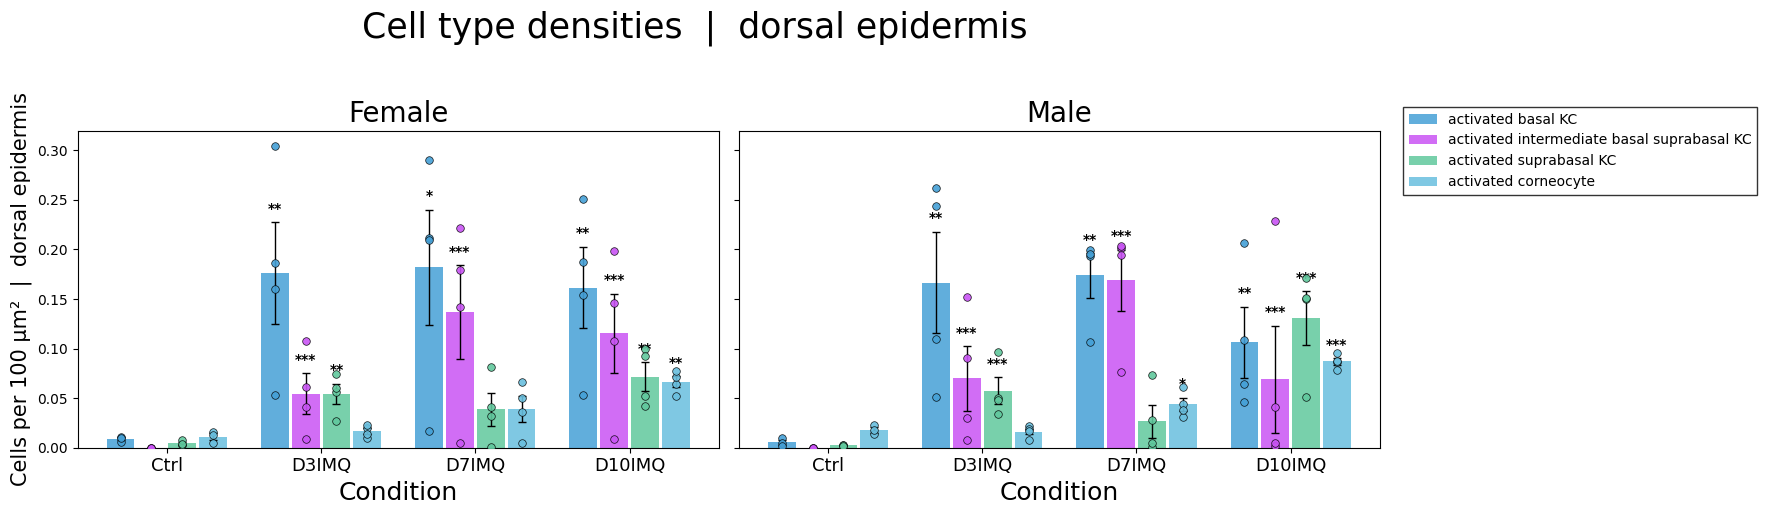

In [39]:
celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order, file_name = 'activated_KCs_density.png')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\3962423803.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


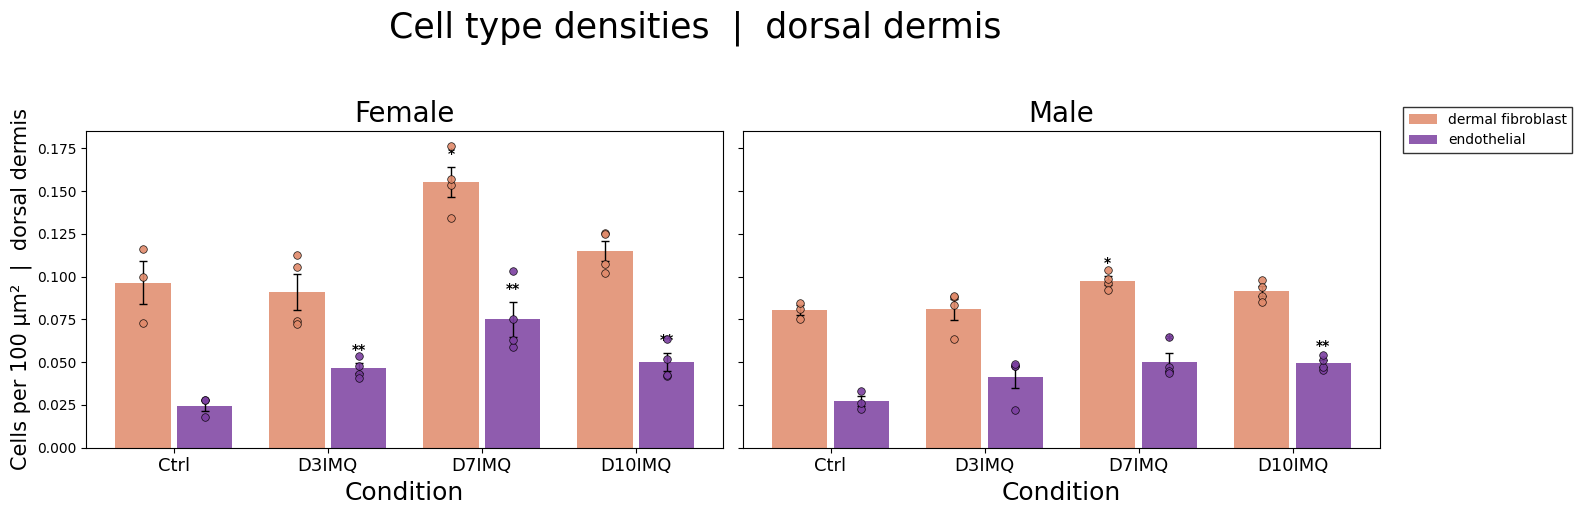

In [46]:
celltypes = ['dermal_fibroblast', 'endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order, file_name = 'stromal_densities.png')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_34224\3962423803.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


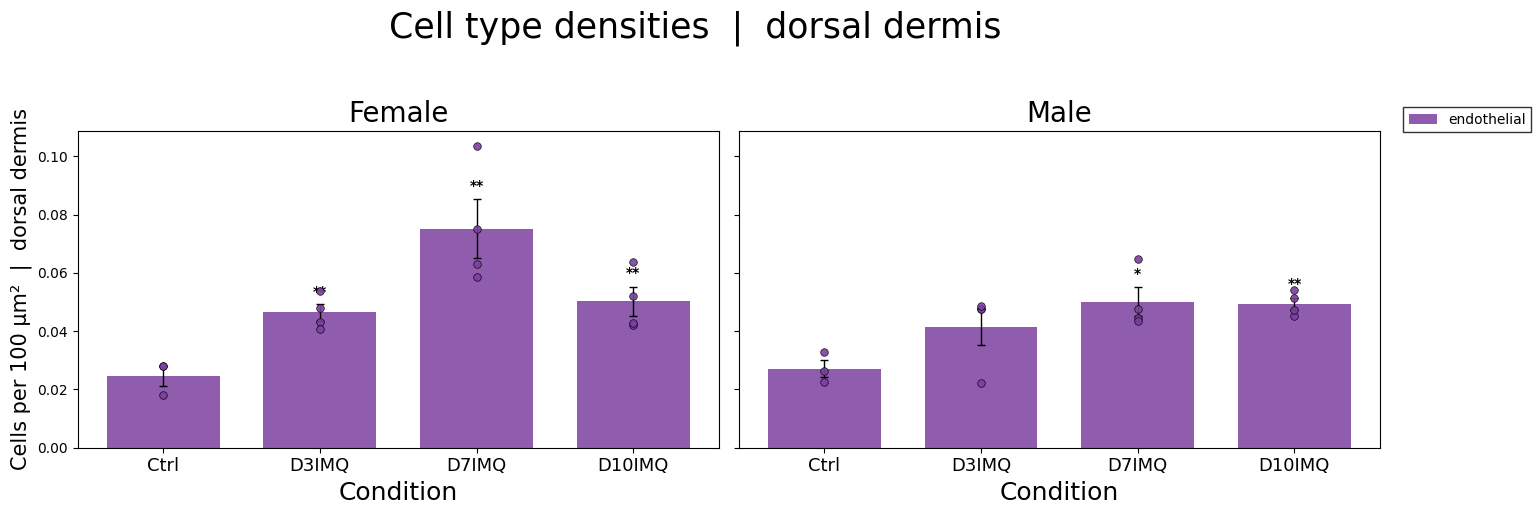

In [45]:
celltypes = ['endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)

## Basal cell proportions

### grouped barplot

In [67]:
def plot_grouped_proportions(adata, celltypes, condition_order=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    # Ensure types are string for clean matching/regex extraction
    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    # If no order is given, dynamically extract unique base conditions from batch keys
    if condition_order is None:
        extracted_conds = adata.obs['batch_key'].str.extract(r'^(.+)_[FM]\d+$')[0]
        condition_order = sorted(extracted_conds.dropna().unique())

    # ── Build per-replicate data structure ───────────────────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # 1. Grab raw counts for each targeted cell type per replicate
    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)

    # 2. Calculate the denominator (sum of ONLY the selected cell types)
    all_batches['total_selected_counts'] = all_batches[celltypes].sum(axis=1)

    # 3. Compute relative proportions (fraction between 0 and 1)
    for ct in celltypes:
        # fillna(0) handles rare edge-case replicates that might have 0 counts for all selected cell types
        all_batches[ct] = (all_batches[ct] / all_batches['total_selected_counts']).fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            # Plot bars
            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            # Overlay individual replicate data points
            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    # Informative Y-axis indicating relative profiling
    axes[0].set_ylabel('Proportion of Selected Cells (Fraction)', fontsize=12)

    # Reconstruct the legend context
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Relative Cell Type Proportions', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\3575533633.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


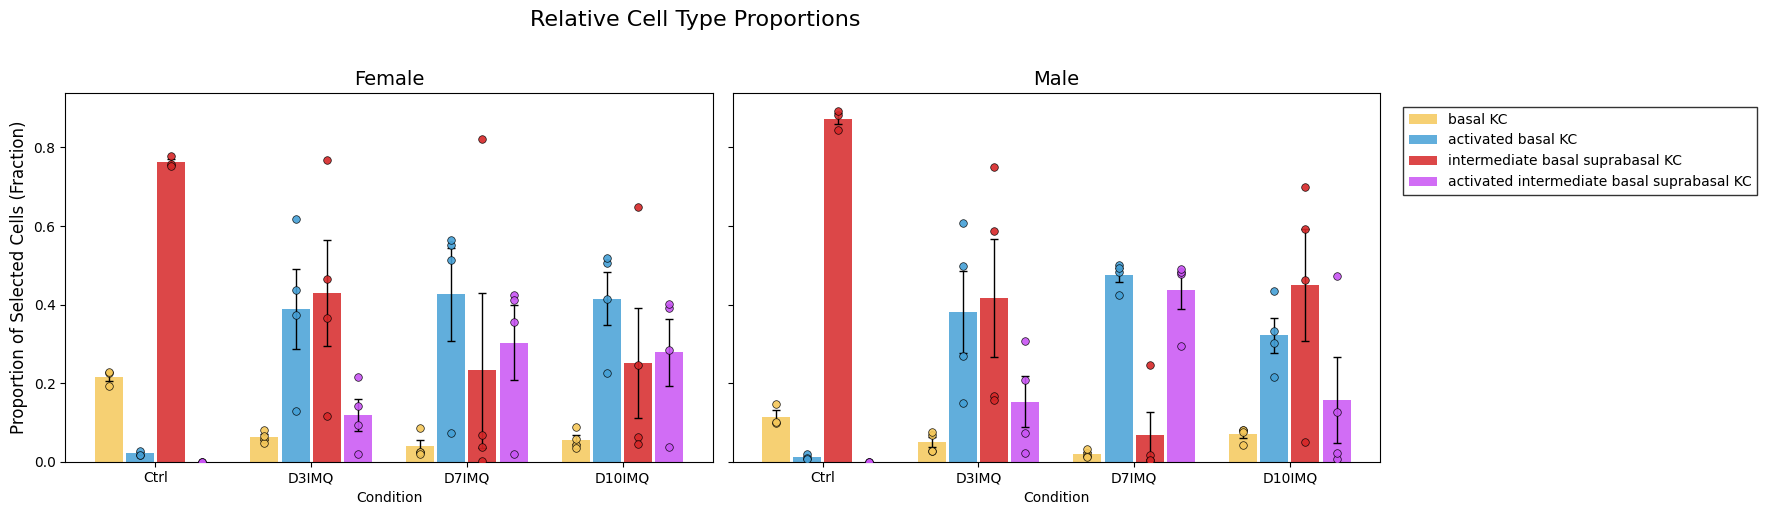

In [70]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
celltypes = ['basal_KC', 'activated_basal_KC', 'intermediate_basal_suprabasal_KC', 'activated_intermediate_basal_suprabasal_KC']

plot_grouped_proportions(adata, celltypes, condition_order=condition_order) #make sure to use adata with ONLY DORSAL SIDE, as this is compartment agnostic

### stacked barplot

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

def plot_stacked_proportions(adata, celltypes, condition_order=None, file_name=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    adata.obs['batch_key']            = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    if condition_order is None:
        extracted_conds = adata.obs['batch_key'].str.extract(r'^(.+)_[FM]\d+$')[0]
        condition_order = sorted(extracted_conds.dropna().unique())

    # ── Build per-replicate data structure ───────────────────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)

    all_batches['total_selected_counts'] = all_batches[celltypes].sum(axis=1)

    for ct in celltypes:
        all_batches[ct] = (all_batches[ct] / all_batches['total_selected_counts']).fillna(0)

    # ── Significance testing ──────────────────────────────────────────────────
    ctrl     = condition_order[0]
    non_ctrl = condition_order[1:]

    def compute_significance(sex_data):
        sig = {}
        for ct in celltypes:
            ctrl_vals = sex_data.loc[sex_data['condition'] == ctrl, ct].values
            raw_pvals = []
            for cond in non_ctrl:
                cond_vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                    _, p = stats.ttest_ind(
                        np.log(ctrl_vals + 1e-9),
                        np.log(cond_vals + 1e-9)
                    )
                else:
                    p = 1.0
                raw_pvals.append(p)

            _, corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')

            for cond, p_corr in zip(non_ctrl, corrected):
                if p_corr < 0.001:
                    sig[(ct, cond)] = '***'
                elif p_corr < 0.01:
                    sig[(ct, cond)] = '**'
                elif p_corr < 0.05:
                    sig[(ct, cond)] = '*'
        return sig

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    x            = np.arange(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]
        sig      = compute_significance(sex_data)
        bottom   = np.zeros(n_conditions)

        for ct in celltypes:
            means = []
            for cond in condition_order:
                cond_data = sex_data.loc[sex_data['condition'] == cond, ct]
                val = cond_data.mean()
                means.append(val if pd.notna(val) else 0.0)

            means = np.array(means)

            ax.bar(
                x, means, bottom=bottom, width=0.6,
                color=color_map[ct], alpha=0.85,
                edgecolor='black', linewidth=0.8
            )

            # Place star in the middle of this segment if significant
            for j, cond in enumerate(condition_order):
                if (ct, cond) in sig:
                    star_y = bottom[j] + means[j] / 2
                    ax.text(
                        x[j], star_y, sig[(ct, cond)],
                        ha='center', va='center', fontsize=10,
                        color='white', fontweight='bold'
                    )

            bottom += means

        ax.set_xticks(x)
        ax.set_xticklabels(condition_order, fontsize=13)
        ax.set_title(sex_labels[sex], fontsize=20)
        ax.set_xlabel('Condition', fontsize=18)
        ax.set_ylim(0, 1.05)

    axes[0].set_ylabel('Relative Proportion (Fraction)', fontsize=15)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Stacked Cell Type Proportions', fontsize=25, y=1.02)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{file_name}", dpi=500, bbox_inches='tight')
    plt.show()

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


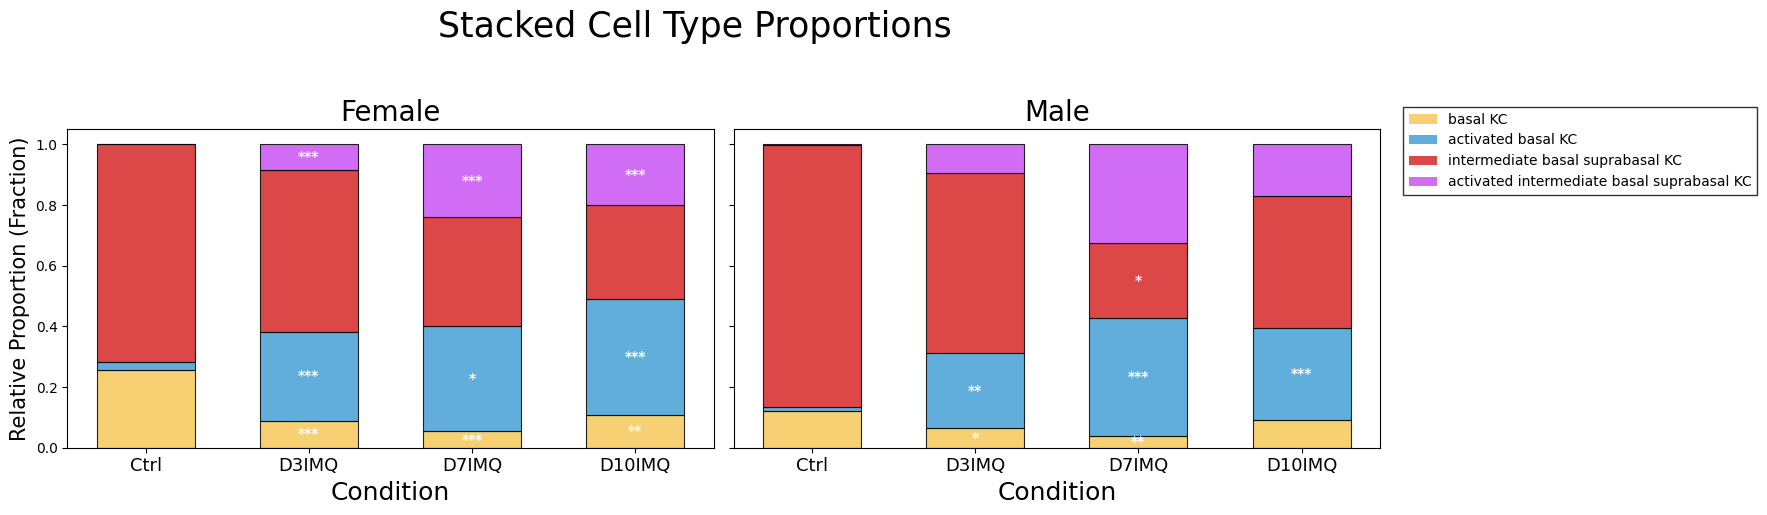

In [49]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
celltypes = ['basal_KC', 'activated_basal_KC', 'intermediate_basal_suprabasal_KC', 'activated_intermediate_basal_suprabasal_KC']

plot_stacked_proportions(adata, celltypes, condition_order=condition_order, file_name = 'Basal_cells_stacked.png')

# DESEQ section

In [32]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
from gseapy import gseaplot

In [2]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

In [34]:
import decoupler as dc

#making pseudobulk objects for the epidermis
adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_epi.n_obs)
sc.pp.filter_genes(adata_epi, min_cells=min_cells)


big_bulk_epidermis = dc.pp.pseudobulk(
    adata_epi,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)


#making pseudobulk objects for the dermis
adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_derm.n_obs)
sc.pp.filter_genes(adata_derm, min_cells=min_cells)

big_bulk_dermis = dc.pp.pseudobulk(
    adata_derm,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
#Creating separate objects for males and females

def isolate_sex(adata, sex_str):
    bdata = adata[adata.obs.replicate.str.contains(sex_str)].copy()
    return bdata

bulk_objects = {'big_bulk_epidermis':big_bulk_epidermis, 'big_bulk_dermis':big_bulk_dermis}

bulk_subtypes = {}
for name, obj in bulk_objects.items():
    #bulk_subtypes[name] = obj #can remove this if you don't care about non-sex differences
    for sex in ['F', 'M']:
        bulk_subtypes[f'{name}_{sex}'] = isolate_sex(obj, sex)

for name, obj in bulk_subtypes.items():
    print(name)
    print(obj)

big_bulk_epidermis_F
AnnData object with n_obs × n_vars = 15 × 2144
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'compartment', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'sex', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', 'n_cells'
    layers: 'psbulk_props'
big_bulk_epidermis_M
AnnData object with n_obs × n_vars = 15 × 2144
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'compartment', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'sex', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', 'n_cells'
    layers: 'psbulk_props'
big_bulk_dermis_F
AnnData object with n_obs × n_vars = 15 × 937
    obs: 'batch_key', 'control_p

In [36]:
from pathlib import Path
results_path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results")

In [42]:
#defining helper function for volcano plotting
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text   # pip install adjustText

def volcano_plot(df, title, save_dir):
    df = df.dropna(subset=['log2FoldChange', 'padj'])
    df['-log10padj'] = -np.log10(df['padj'])

    fc_thresh = 1.0
    padj_thresh = 0.05
    n_labels = 20  # number of top genes to label

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all points
    colours = np.where(
        (df['padj'] < padj_thresh) & (df['log2FoldChange'] > fc_thresh), 'firebrick',
        np.where(
            (df['padj'] < padj_thresh) & (df['log2FoldChange'] < -fc_thresh), 'steelblue', 'lightgrey'
        )
    )
    ax.scatter(df['log2FoldChange'], df['-log10padj'], c=colours, alpha=0.6, s=15)

    # Label top genes by significance
    top_genes = df.nsmallest(n_labels, 'padj')
    texts = [
        ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', linewidth=0.8)
    ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=0.8)

    ax.set_xlabel('log2 Fold Change')
    ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    
    # save_path = save_dir / (title)
    # plt.savefig(save_path, bbox_inches='tight', dpi = 400)
    # plt.close()
    plt.show()

In [37]:
#helper function for enrichment map plotting
from gseapy import enrichment_map
import networkx as nx
import textwrap

def enrichment_plot(pre_res, output_path):

    nodes, edges = enrichment_map(pre_res.res2d)
    G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])
    
    fig, ax = plt.subplots(figsize=(8, 8))
    pos = nx.layout.spiral_layout(G)

    nodelist = list(G.nodes())
    nodes_aligned = nodes.loc[nodelist]

    nx.draw_networkx_nodes(G,
                        pos=pos,
                        nodelist=nodelist,
                        cmap=plt.cm.RdYlBu,
                        node_color=list(nodes_aligned.NES),
                        node_size=list(nodes_aligned.Hits_ratio * 1000))

    # wrap labels and draw with clip_on=False
    wrapped_labels = {
        node: '\n'.join(textwrap.wrap(term, width=20))
        for node, term in nodes_aligned.Term.to_dict().items()
    }
    label_objs = nx.draw_networkx_labels(G, pos=pos, labels=wrapped_labels, font_size=7)
    for _, text in label_objs.items():
        text.set_clip_on(False)

    edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
    nx.draw_networkx_edges(G,
                        pos=pos,
                        width=list(map(lambda x: x*10, edge_weight)),
                        edge_color='#CDDBD4')
    
    x_values = [pos[n][0] for n in G.nodes()]
    y_values = [pos[n][1] for n in G.nodes()]

    max_label_len = max(len(t) for t in nodes_aligned.Term)
    pad = 0.3 + (max_label_len * 0.01)

    ax.set_xlim(min(x_values) - pad, max(x_values) + pad)
    ax.set_ylim(min(y_values) - pad, max(y_values) + pad)

    plt.tight_layout()
    plt.savefig(output_path, dpi=400, bbox_inches='tight')
    plt.close()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_1356\665023891.py:14: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = bulk.X,
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.39 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.37 seconds.

Fitting LFCs...
... done in 0.31 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


F


... done in 0.28 seconds.



...

Using None as control genes, passed at DeseqDataSet initialization


... done in 0.21 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


M


... done in 0.21 seconds.



Log2 fold change & Wald test p-value: condition D3IMQ vs Ctrl
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Aatf     23.440309       -0.751699  0.377362 -1.991984  0.046373  0.236149
Abca1    76.806300       -0.526896  0.277158 -1.901067  0.057293  0.261502
Abca7    36.265019        0.044577  0.296777  0.150205  0.880603  0.960565
Abcc1    15.211495        0.215644  0.431363  0.499913  0.617136  0.836523
Abcf1    17.595919       -0.329935  0.385114 -0.856721  0.391599  0.706991
...            ...             ...       ...       ...       ...       ...
Zc3h11a  23.010033       -0.134442  0.384161 -0.349963  0.726367  0.888519
Zdhhc8   19.118576       -0.561774  0.374025 -1.501968  0.133105  0.406254
Zeb2     33.662585       -0.122738  0.338235 -0.362878  0.716696  0.884469
Zfp106   30.506359       -0.116107  0.354243 -0.327762  0.743091  0.894357
Zzef1    17.285826        0.761609  0.459472  1.657576  0.097403  0.333918

[937 rows x 6 columns]
M
succeeded 2


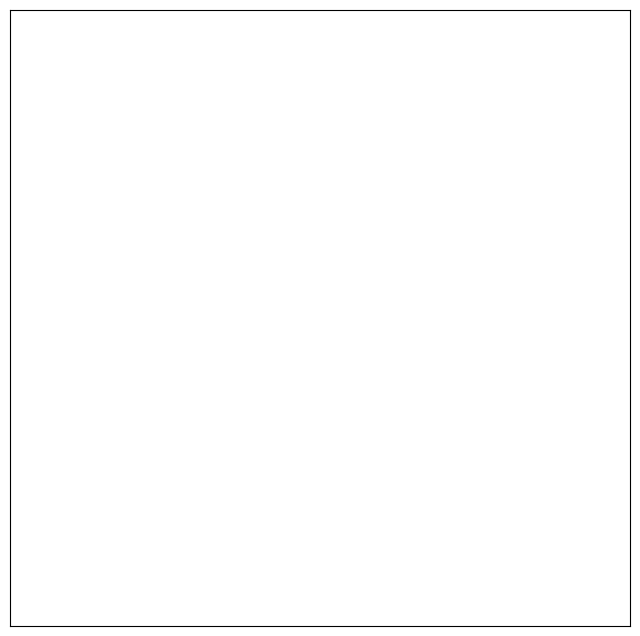

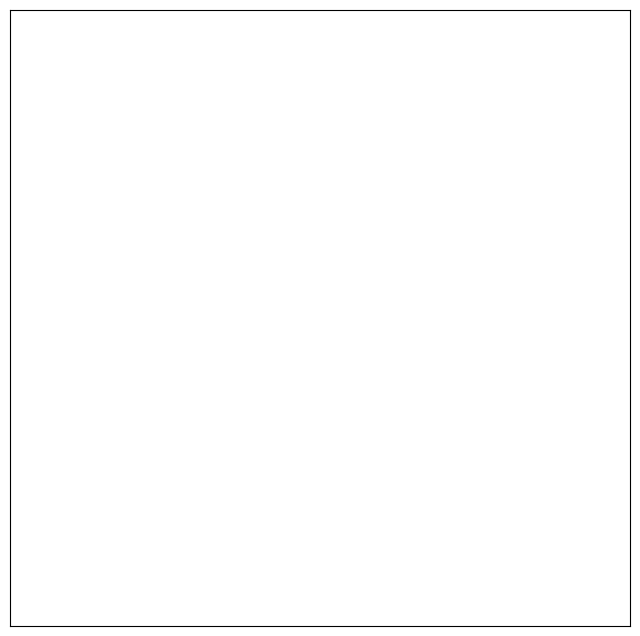

In [39]:
#run on a whole dictionary - single object workflow in following cells
failed_deseq2 = []
low_DEs = []
small_GSEAs = []
failed_enrichments = []

for name, bulk in bulk_subtypes.items():
    #make a deseq data set from your anndata
    
    ###avoid recalculating if already done###
    # if Path(results_path/ f'{name}_Ctrl_D3IMQ_DEgenes.csv').exists(): #bit jammy, but if D3 is calced, then so are D7/D10
    #     continue

    dds = DeseqDataSet(counts = bulk.X,
                   metadata = bulk.obs,
                   design_factors = 'condition')
    dds.var = bulk.var


    #run deseq2 on it
    try:
        dds.deseq2()
    except:
        failed_deseq2.append(f'{name}')
        continue

    #get the stats
    for day in ['D3IMQ']:
        print(name.split("_")[3])
        print("="*80)


        stat_res = DeseqStats(dds, contrast = ['condition', day, 'Ctrl']) #pairwise comparison of days with each condition
        stat_res.summary()
        #get diffexp dataframe
        res = stat_res.results_df
        res_file = f'{name}_Ctrl_{day}_DEgenes.csv'
        res.to_csv(results_path / res_file) #save table with stats of DE genes
        
        #filtering any genes with baseMean <10, choice is somewhat arbitrary
        res = res[res.baseMean >10]
        #then filter all those that are not significant or large enough
        sigs = res[(abs(res.log2FoldChange) > 1)&(res.padj <0.05)] #again, log2fc threshold is bit arbitrary,being stringent so using 1.
        #check if yap1 is in the list of significantly expressed genes
        if 'Yap1' in sigs.index.to_list():
            print(f'{name}_Ctrl_{day} has a significant change in YAP1')
        
        # #plot VOLCANO PLOT and save
        # volcano_plot_name = f'{name}_Ctrl_{day}_volcano.png'

        # save_dir = results_path / 'Volcano_plots'
        # volcano_plot(res, volcano_plot_name, save_dir)
        
        # #plot CLUSTERMAP for significant genes
        # cluster_map_name = f'{name}_Ctrl_{day}_cluster.png'
        # cluster_map_path = results_path / 'clustermaps' / cluster_map_name
        # if len(sigs) >2:
        #     dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
        #     dds_sigs = dds[:, sigs.index].copy()

        #     grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
        #                 index = dds_sigs.var_names, columns = dds_sigs.obs_names)
            
        #     clustermap = sns.clustermap(grapher, z_score = 0, cmap = 'RdYlBu_r')
        #     clustermap.savefig(cluster_map_path, bbox_inches = 'tight', dpi = 400)
        #     plt.close(clustermap.fig)
        # else:
        #     low_DEs.append(f'{name}_Ctrl_{day}')

        #do GSEA on your diffexped genes
        ranking = res['stat'].dropna().sort_values(ascending = False)

        for gene_set in ['GO_Biological_Process_2026', 'KEGG_2026']:
            if gene_set == 'GO_Biological_Process_2026':
                database = 'GO'
            else:
                database = 'KEGG' 
            
            try:
                pre_res = gp.prerank(rnk = ranking,
                        gene_sets = gene_set, #this can be a list, e.g. if you wanted to look at molecular function, or KEGG
                        organism = 'mouse',
                        seed = 6, permutation_num=100)
                
                print(name.split("_")[3])
                if name.split("_")[3] == 'F':
                    sex = 'female'
                else:
                    sex = 'male'
                
                dot_title = f'{name.split("_")[2]} {sex} Ctrl {day} {database}'
                ax = gp.dotplot(pre_res.res2d,
                            column="FDR q-val",
                            title=dot_title,
                            cmap=plt.cm.RdBu_r,
                            size=4, # adjust dot size
                            figsize=(4,5), 
                            cutoff=0.25, 
                            show_ring=False,
                            ofname=str(results_path / 'GSEA_plots' / f'{name.split("_")[2]} {sex} Ctrl {day} {database}_dotplot.png'))

                out = []
                for term in list(pre_res.results):
                    out.append([term,
                                pre_res.results[term]['fdr'],
                                pre_res.results[term]['es'],
                                pre_res.results[term]['nes']])
                print("succeeded 2")
                    
                out_df = pd.DataFrame(out, columns = ['Term', 'fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
                out_df.sort_values('nes', ascending = False)
                print("succeeded 3")



                out_df.to_csv(results_path / 'GSEA_csvs' / f'{name}_Ctrl_{day}_{database}.csv')

                #plotting the ENRICHMENT MAP
                output_path = results_path / 'GSEA_plots'/ f'{name}_Ctrl_{day}_{database}.png'
                try:
                    enrichment_plot(pre_res, output_path)
                except:
                    print(f'no signficant {database} terms for {name}_D3IMQ{day}')
                    failed_enrichments.append(f'{name}_Ctrl_{day}_{database}')
            except:
                small_GSEAs.append(f'{name}_Ctrl_{day}_{database}')


print(failed_deseq2) 
print(low_DEs) 
print(small_GSEAs) 
print(failed_enrichments)

In [ ]:
from gseapy import dotplot
# to save your figure, make sure that ``ofname`` is not None
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG_2016',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff=0.25, show_ring=False)

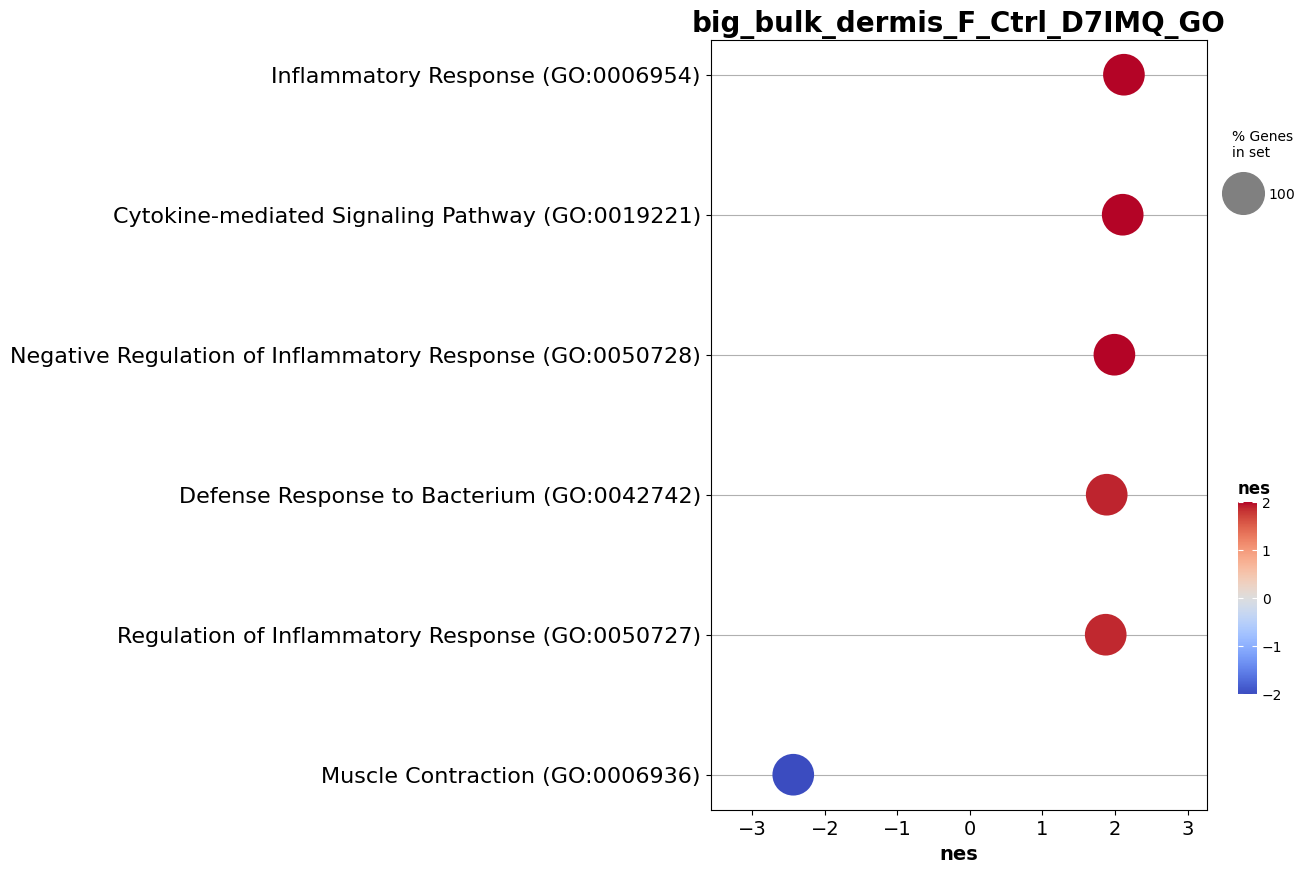

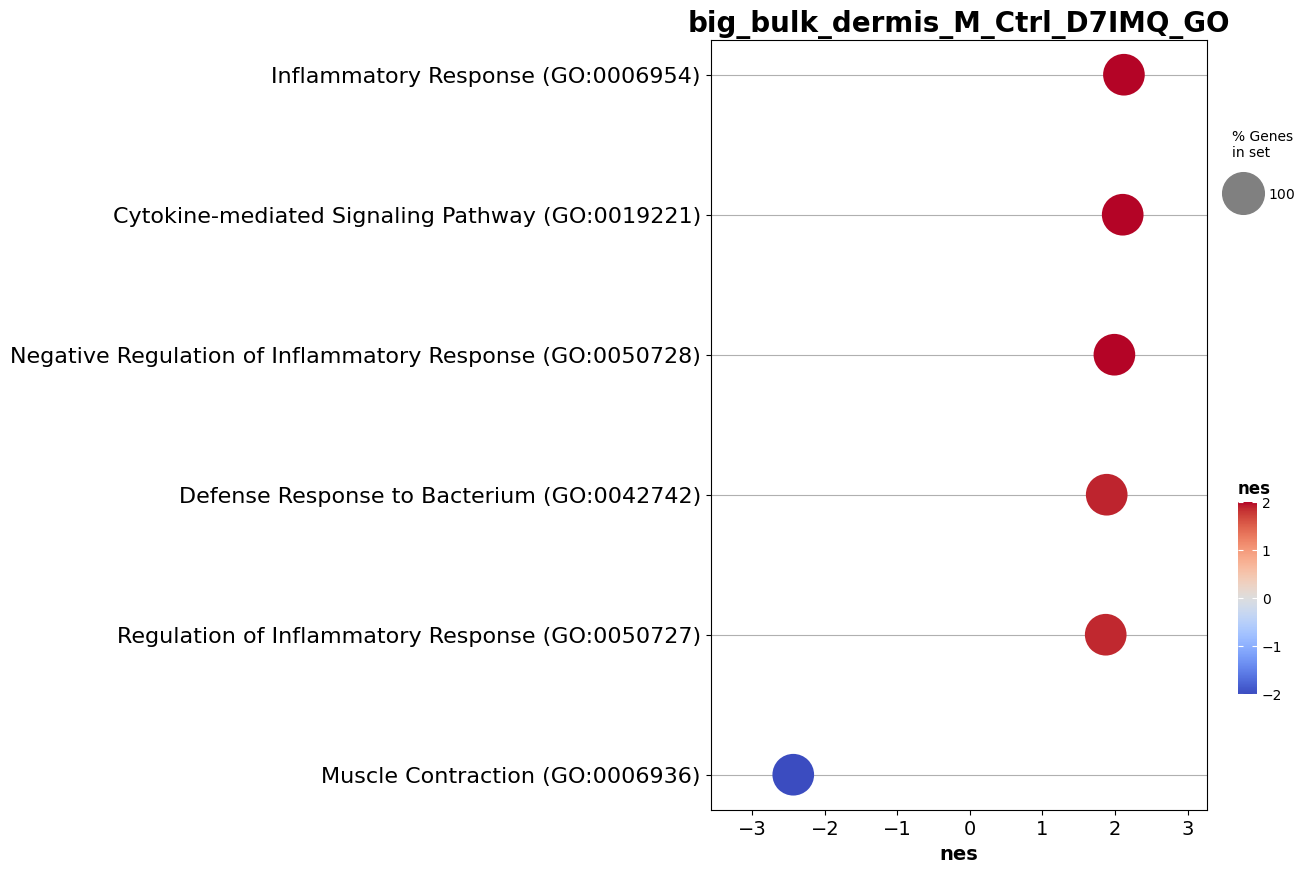

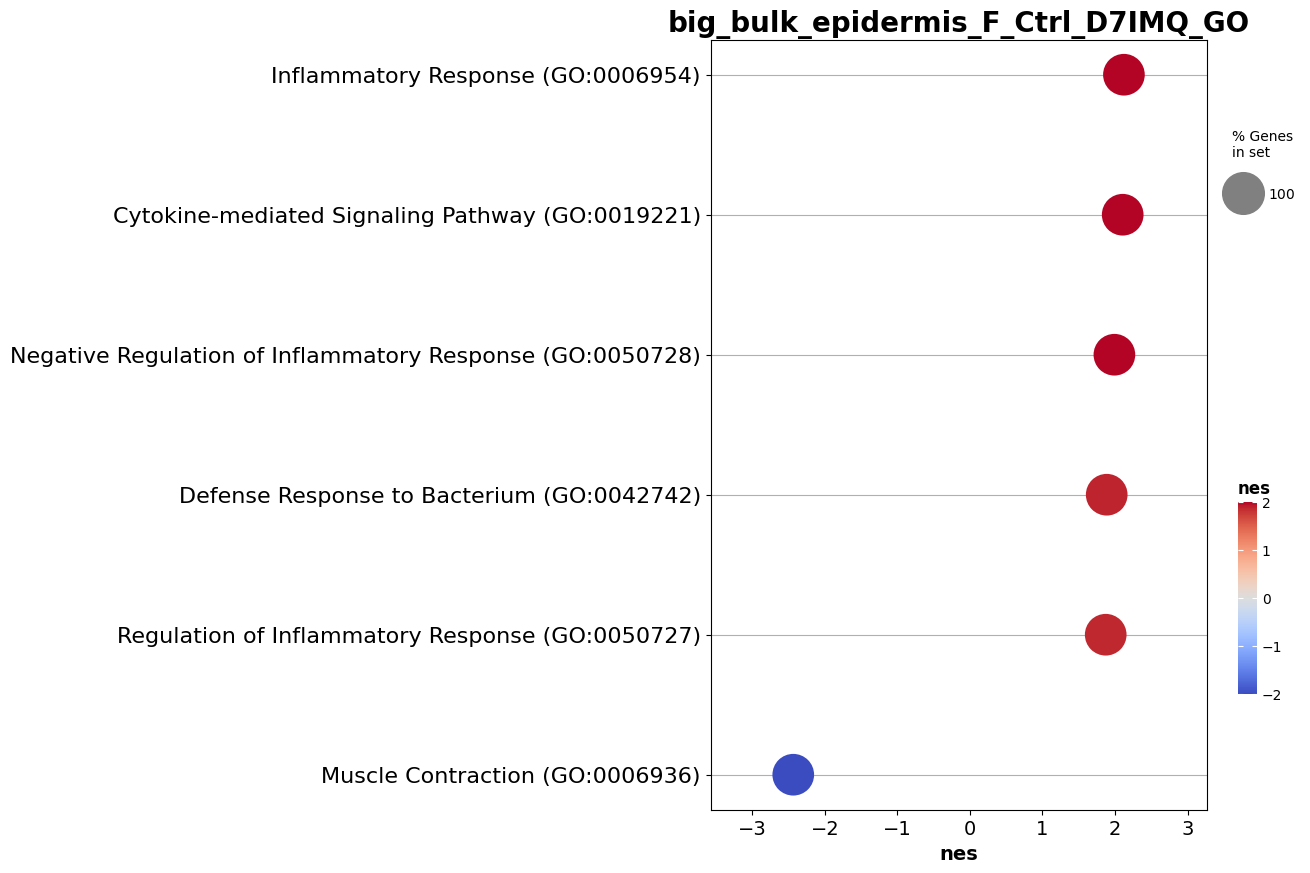

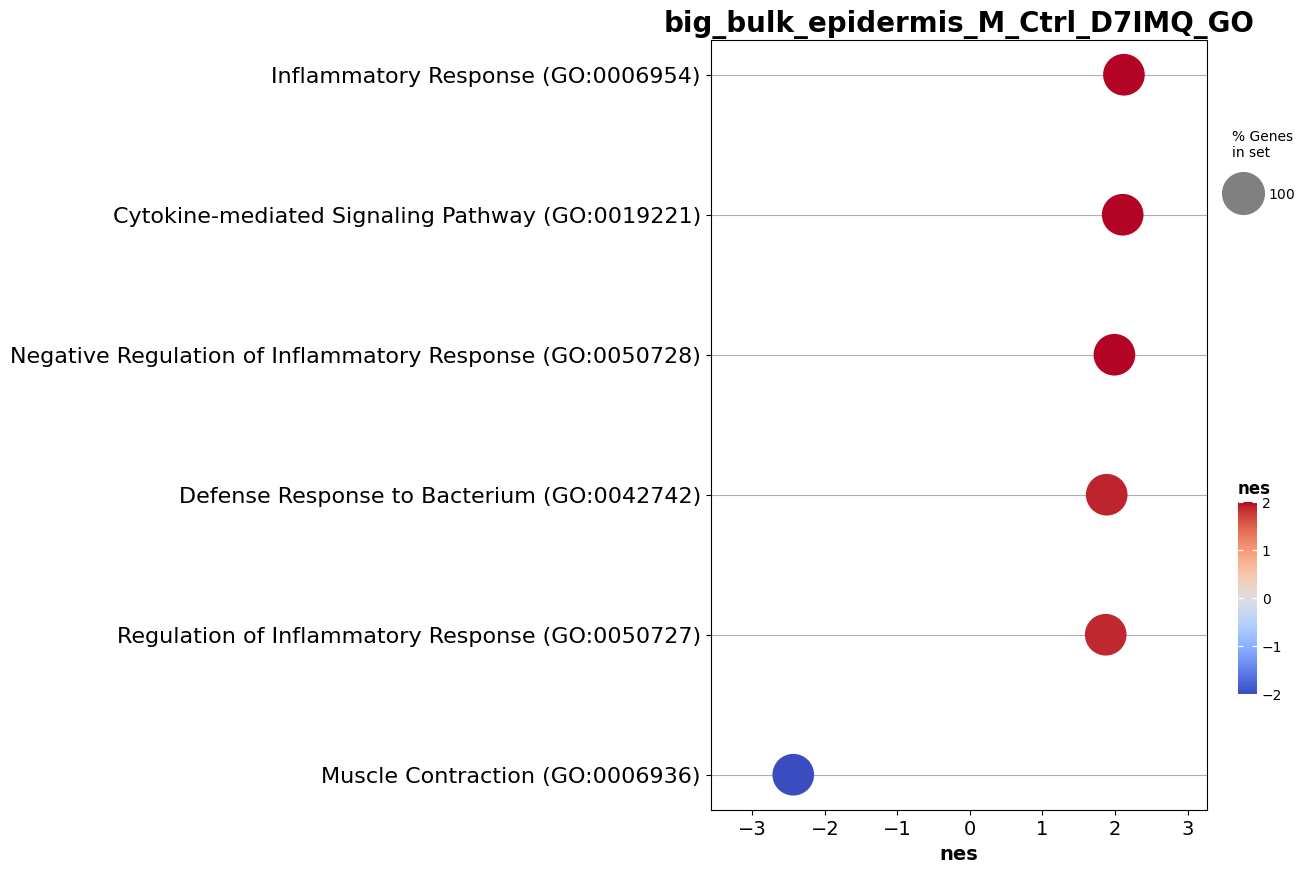

In [27]:
for name, df in out_dfs.items():
    filtered = out_df[0][out_df[0]['fdr'] < 0.05]
    gp.dotplot(
        filtered,
        column="nes",       # dot size and x-axis
        title=name,
        cmap="coolwarm",
        size=5,
        figsize=(8, 10),
        cutoff=999,
        show_ring=False
    )

## replotting volcano plots

In [42]:
import pandas as pd #run volcano plot helper function
from pathlib import Path

results_path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results")

results = {}
for file in results_path.glob("*.csv"):
    if 'unique' in file.stem:
        continue
    results[file.stem] = pd.read_csv(file, index_col=0)
len(results)

12

## specific labelled volcanos

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

def volcano_plot_dual(df_tuples, title, save_dir=None, n_labels=20, label_genes=None):
    """
    Plots two volcano plots side-by-side with shared axis limits.
    
    Parameters:
    df_tuples:    list/tuple of two tuples, e.g., [('Condition A', df1), ('Condition B', df2)]
    title:        str, overall figure title
    save_dir:     Path or str, directory to save the plot (optional)
    n_labels:     int, number of top significant genes to label (ignored if label_genes is set)
    label_genes:  list of str, specific gene names to label if present in the data.
                  If provided, overrides n_labels behaviour.
    """
    if len(df_tuples) != 2:
        raise ValueError("This function specifically expects exactly two (name, dataframe) tuples.")

    fc_thresh = 1.0
    padj_thresh = 0.05

    processed_dfs = []
    global_max_fc = 0
    global_max_log_p = 0

    for name, df in df_tuples:
        clean_df = df.dropna(subset=['log2FoldChange', 'padj']).copy()
        clean_df['-log10padj'] = -np.log10(clean_df['padj'])
        processed_dfs.append((name, clean_df))
        global_max_fc = max(global_max_fc, clean_df['log2FoldChange'].abs().max())
        global_max_log_p = max(global_max_log_p, clean_df['-log10padj'].max())

    xlims = (-global_max_fc * 1.1, global_max_fc * 1.1)
    ylims = (0, global_max_log_p * 1.05)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for i, (name, df) in enumerate(processed_dfs):
        ax = axes[i]

        colours = np.where(
            (df['padj'] < padj_thresh) & (df['log2FoldChange'] > fc_thresh), 'firebrick',
            np.where(
                (df['padj'] < padj_thresh) & (df['log2FoldChange'] < -fc_thresh), 'steelblue', 'lightgrey'
            )
        )

        ax.scatter(df['log2FoldChange'], df['-log10padj'], c=colours, alpha=0.6, s=15)

        # Select genes to label
        if label_genes is not None:
            genes_to_label = df[df.index.isin(label_genes)]
        else:
            genes_to_label = df.nsmallest(n_labels, 'padj')

        texts = [
            ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=7)
            for gene, row in genes_to_label.iterrows()
        ]
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

        ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', linewidth=0.8)
        ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=0.8)
        ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=0.8)

        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel('log2 Fold Change')
        ax.set_title(name, fontsize=12)

        if i == 0:
            ax.set_ylabel('-log10 adjusted p-value')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    if save_dir:
        import os
        save_path = os.path.join(save_dir, f"{title.replace(' ', '_')}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=400)
        plt.close()
    else:
        plt.show()

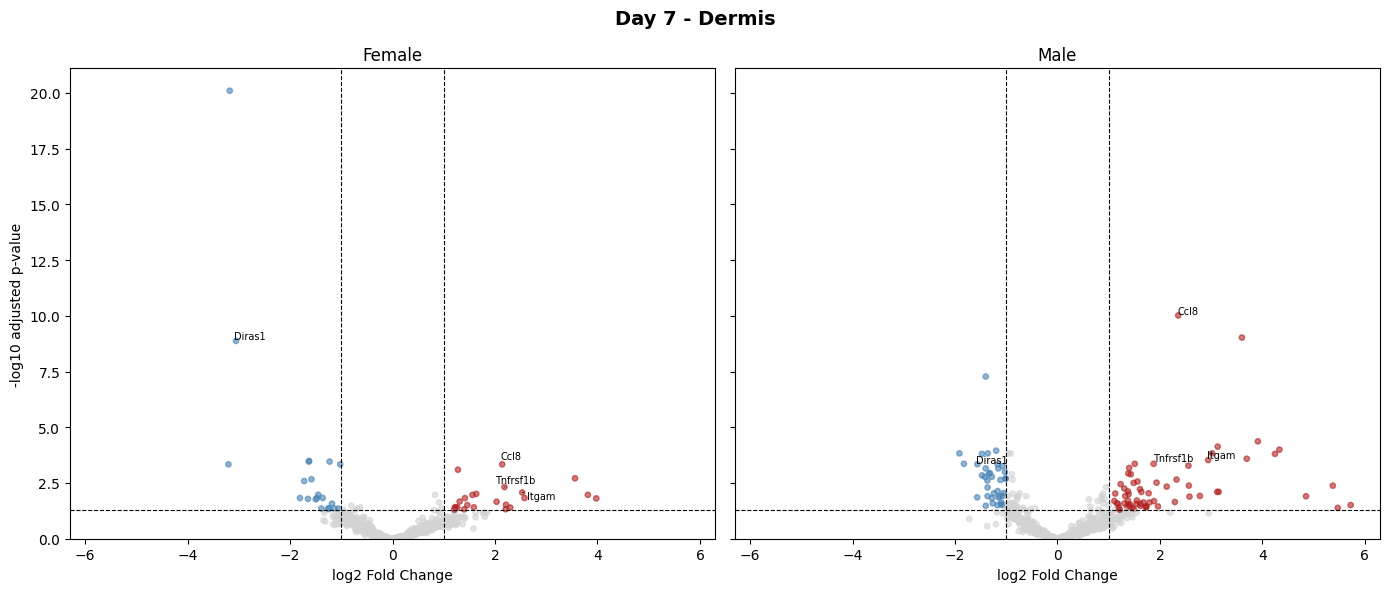

In [44]:
#D7 dermis
d7_derm_f = results['big_bulk_dermis_F_Ctrl_D7IMQ_DEgenes']
d7_derm_m = results['big_bulk_dermis_M_Ctrl_D7IMQ_DEgenes']

volcano_plot_dual([('Female', d7_derm_f), ('Male', d7_derm_m)], 'Day 7 - Dermis', label_genes = ['Tnfrsf1b', 'Itgam', 'Ccl8', 'Diras1'])

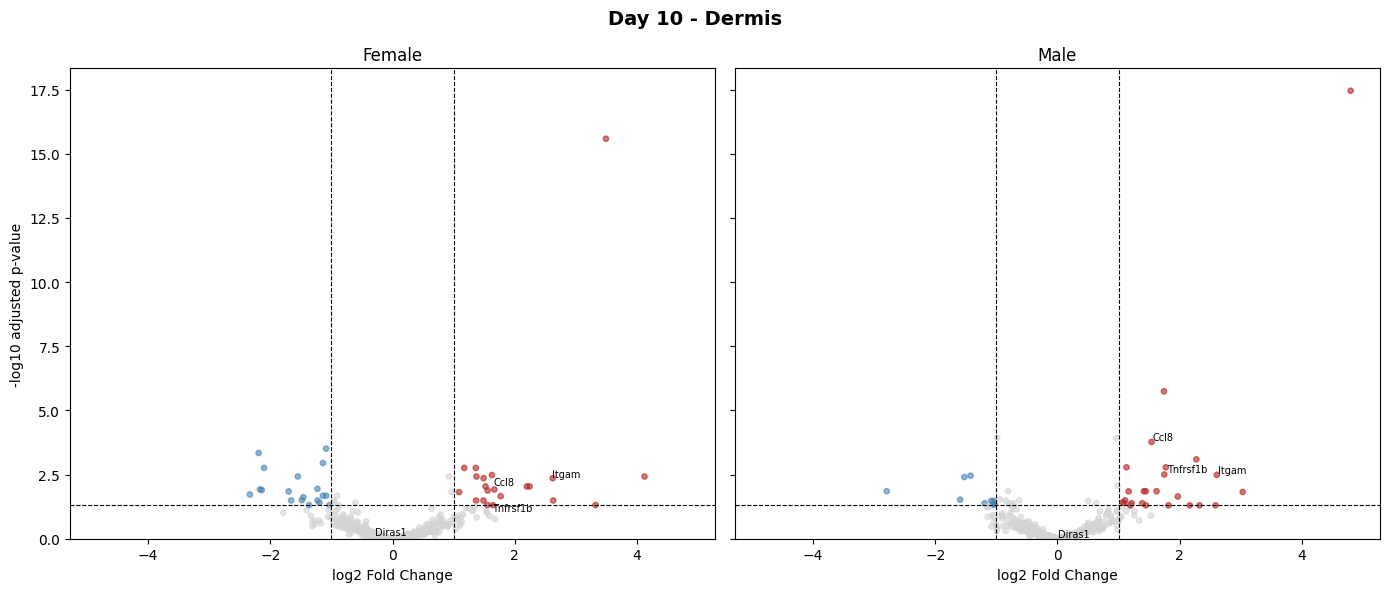

In [45]:
#D7 dermis
d7_derm_f = results['big_bulk_dermis_F_Ctrl_D10IMQ_DEgenes']
d7_derm_m = results['big_bulk_dermis_M_Ctrl_D10IMQ_DEgenes']

volcano_plot_dual([('Female', d7_derm_f), ('Male', d7_derm_m)], 'Day 10 - Dermis', label_genes = ['Tnfrsf1b', 'Itgam', 'Ccl8', 'Diras1'])

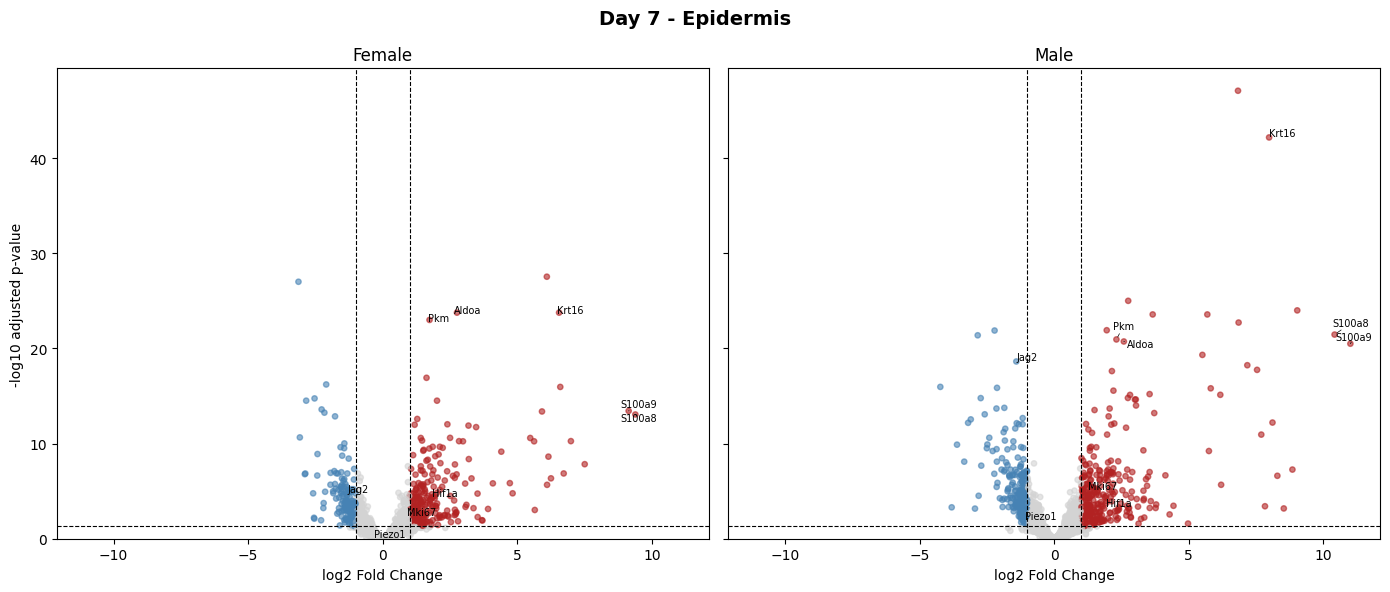

In [18]:
#D7 epidermis
d7_epiderm_f = results['big_bulk_epidermis_F_Ctrl_D7IMQ_DEgenes']
d7_epiderm_m = results['big_bulk_epidermis_M_Ctrl_D7IMQ_DEgenes']

volcano_plot_dual([('Female', d7_epiderm_f), ('Male', d7_epiderm_m)], 'Day 7 - Epidermis', label_genes = ['Pkm', 'Krt16', 'S100a8', 'S100a9', 'Mki67', 'Hif1a', 'Aldoa', 'Jag2', 'Piezo1', 'Ccn1', 'Ccn2'])

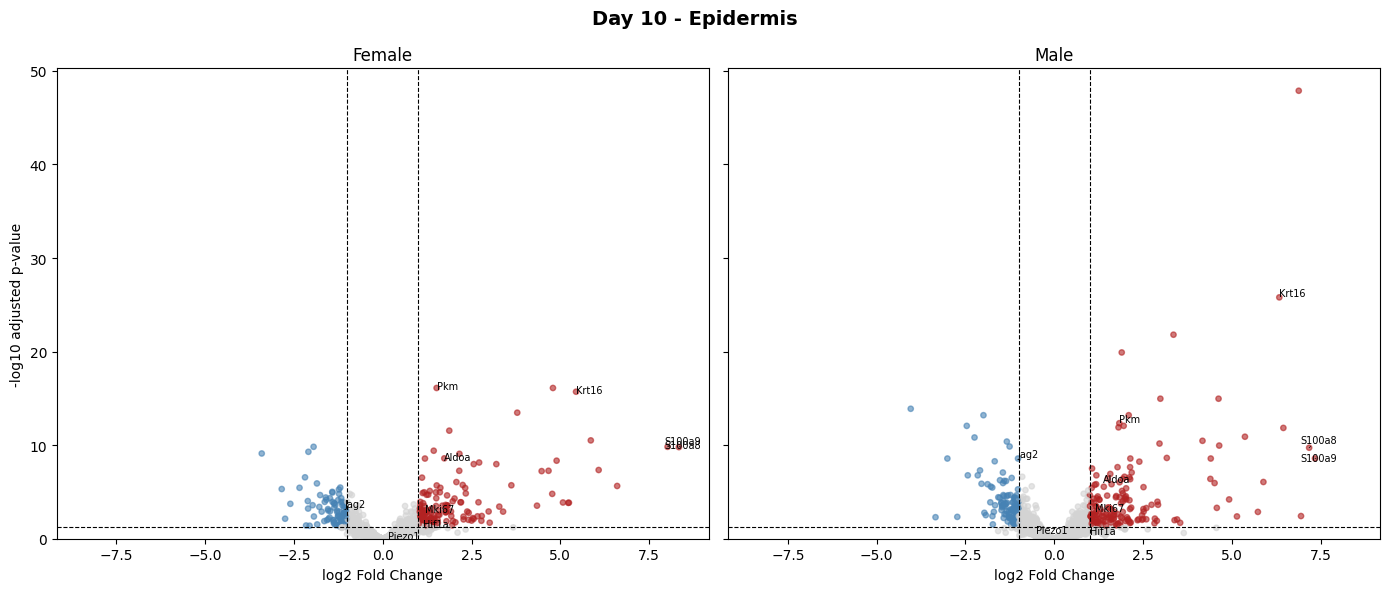

In [19]:
#D7 epidermis
d7_epiderm_f = results['big_bulk_epidermis_F_Ctrl_D10IMQ_DEgenes']
d7_epiderm_m = results['big_bulk_epidermis_M_Ctrl_D10IMQ_DEgenes']

volcano_plot_dual([('Female', d7_epiderm_f), ('Male', d7_epiderm_m)], 'Day 10 - Epidermis', label_genes = ['Pkm', 'Krt16', 'S100a8', 'S100a9', 'Mki67', 'Hif1a', 'Aldoa', 'Jag2', 'Piezo1', 'Ccn1', 'Ccn2'])

## celltype volcanos - and gene list bar plots

### bulk expression frames

In [22]:
from pathlib import Path
import pandas as pd

cell_type = 'myeloid'

path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_celltype_results")

results_dfs = {}

for file in path.glob("myeloid*"):
    name = file.stem.removeprefix(f"{cell_type}_").removesuffix("_DEgenes")

    results_dfs[name] = pd.read_csv(file)

results_dfs

{'F_Ctrl_D10IMQ':     Unnamed: 0   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
 0         Aatf   6.881382       -0.571405  0.716667 -0.797309  0.425272   
 1        Abca1  12.151973        1.509229  0.680574  2.217581  0.026583   
 2        Abca7   8.978907        1.275572  0.941663  1.354595  0.175547   
 3        Abcc1   3.606021       -0.896792  0.820613 -1.092833  0.274467   
 4        Abcf1   3.721454       -0.098822  0.897763 -0.110076  0.912349   
 ..         ...        ...             ...       ...       ...       ...   
 792        Yy1   2.779441        0.884073  1.515968  0.583174  0.559776   
 793    Zc3h11a   3.876368       -1.101313  0.939592 -1.172119  0.241149   
 794       Zeb2   9.363098        0.251420  0.655734  0.383417  0.701410   
 795     Zfp106   3.395640        0.434881  1.158606  0.375348  0.707401   
 796      Zzef1   4.186411        0.791481  1.142819  0.692569  0.488580   
 
          padj  
 0    0.821324  
 1    0.571531  
 2    0.816932  
 

In [39]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results")

results_dfs = {}

for file in path.glob("*_dermis*"):
    name = file.stem.removeprefix(f"big_bulk_dermis_").removesuffix("_DEgenes")

    results_dfs[name] = pd.read_csv(file)

results_dfs

{'F_Ctrl_D10IMQ':     Unnamed: 0   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
 0         Aatf  25.835395       -0.441702  0.394645 -1.119239  0.263038   
 1        Abca1  62.047854        0.788047  0.320163  2.461390  0.013840   
 2        Abca7  29.491863       -0.319463  0.360041 -0.887295  0.374920   
 3        Abcc1  15.412003        0.133499  0.479845  0.278212  0.780850   
 4        Abcf1  16.961779       -0.244119  0.422132 -0.578299  0.563062   
 ..         ...        ...             ...       ...       ...       ...   
 932    Zc3h11a  18.306914       -1.245447  0.423378 -2.941691  0.003264   
 933     Zdhhc8  14.864500        0.116893  0.506176  0.230934  0.817366   
 934       Zeb2  27.888959        0.093586  0.347050  0.269662  0.787420   
 935     Zfp106  26.239420       -0.658097  0.364902 -1.803489  0.071311   
 936      Zzef1  16.663262        0.079097  0.460061  0.171928  0.863494   
 
          padj  
 0    0.563292  
 1    0.115100  
 2    0.691344  
 

In [32]:
ECM_genes = []
for i in results_dfs['F_Ctrl_D10IMQ']['Unnamed: 0']:
    if 'Col' in i:
        ECM_genes.append(i)
    elif 'Tnc' in i:
        ECM_genes.append(i)
    elif 'Fn1' in i:
        ECM_genes.append(i)
    elif 'Mmp' in i:
        ECM_genes.append(i)
    elif 'Vim' in i:
        ECM_genes.append(i)
print(ECM_genes)

['Col18a1', 'Col1a1', 'Col1a2', 'Col3a1', 'Col4a1', 'Col4a2', 'Col5a1', 'Col6a1', 'Col6a2', 'Col6a3', 'Col7a1', 'Fn1', 'Mmp14', 'Mmp2', 'Tnc', 'Vim']


In [29]:
genetype = 'ECM'
#genetype = 'Myeloid Inhibition'

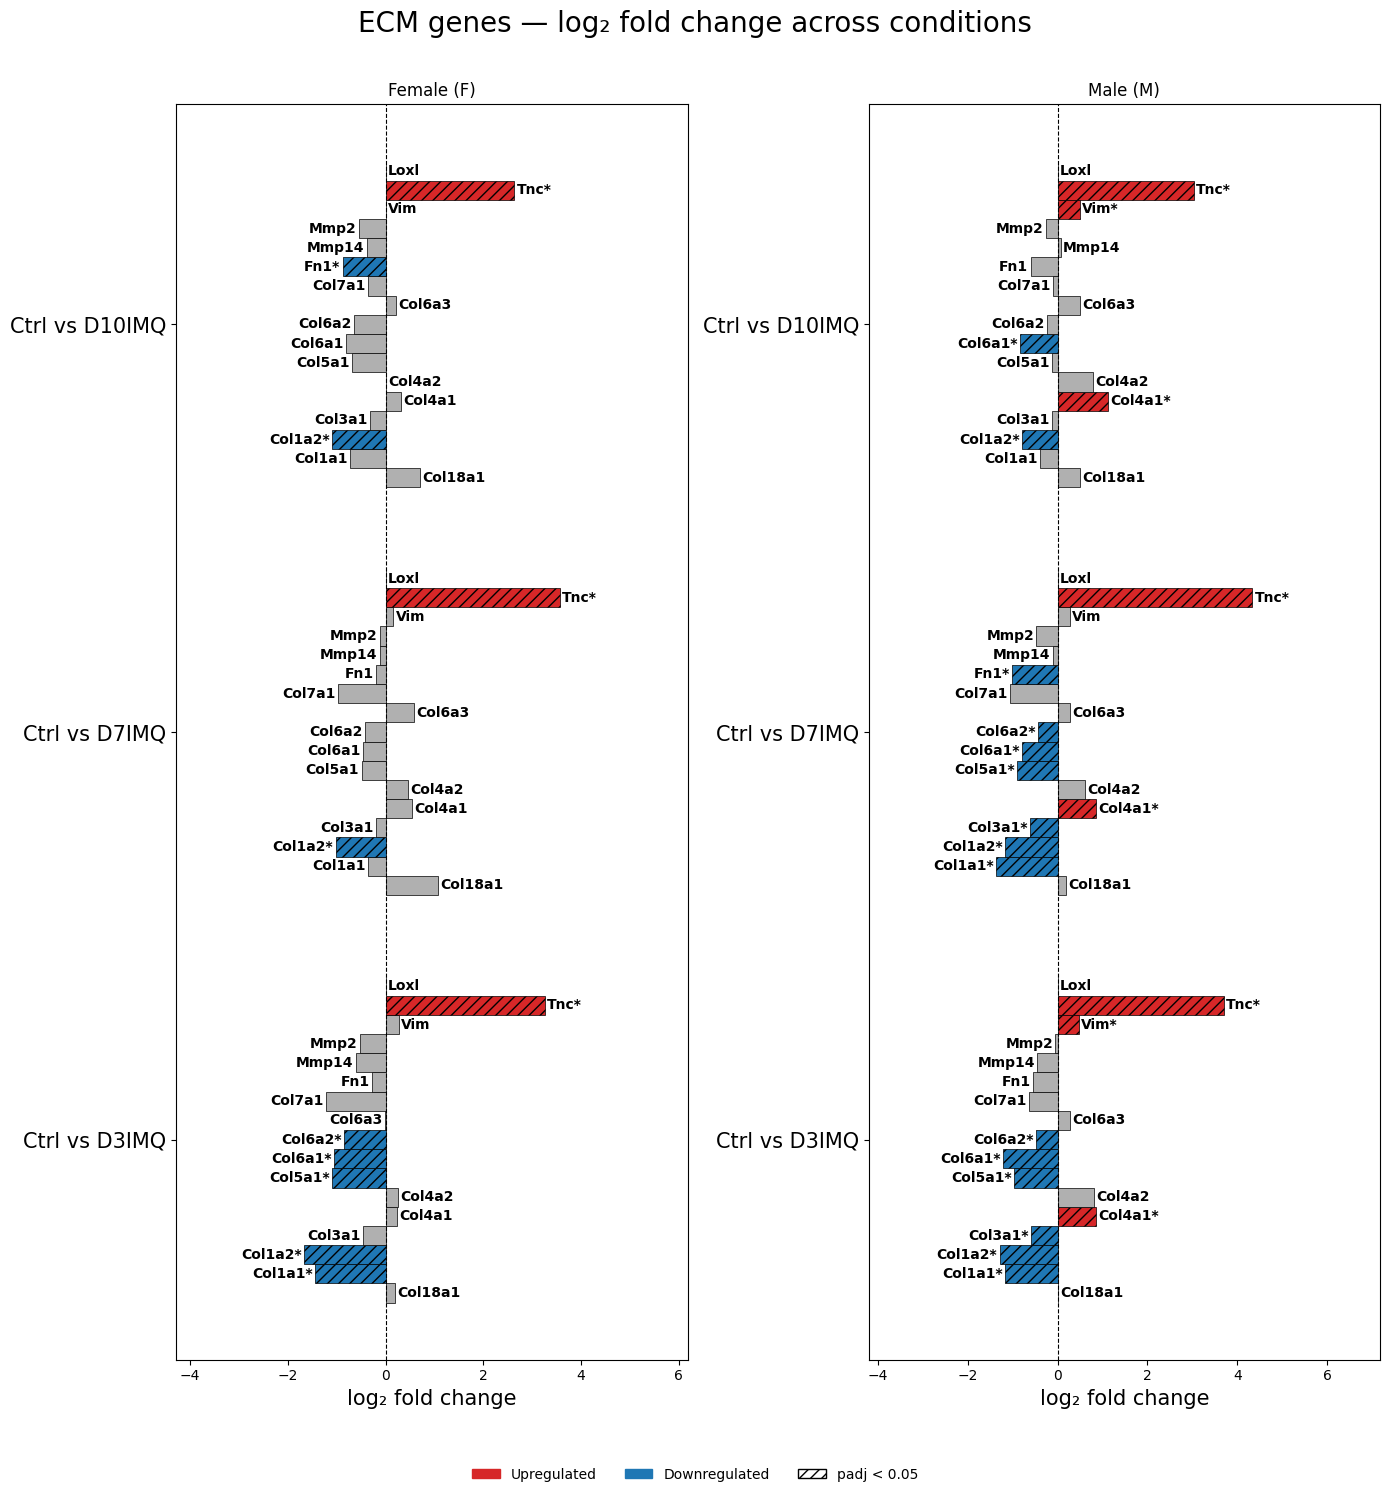

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genes = ['Col18a1', 'Col1a1', 'Col1a2', 'Col3a1', 'Col4a1', 'Col4a2', 'Col5a1', 'Col6a1', 'Col6a2', 'Col6a3', 'Col7a1', 'Fn1', 'Mmp14', 'Mmp2', 'Vim', 'Tnc', 'Loxl']
#genes = ['Cd72', 'Il10ra', 'Ilf5', 'Ilf59']


col = 'Unnamed: 0' #gene column

condition_order = ['Ctrl vs D3IMQ', 'Ctrl vs D7IMQ', 'Ctrl vs D10IMQ', 'D7IMQ vs D10IMQ']


# collect data for all genes
records = {gene: [] for gene in genes}

for name, df in results_dfs.items():
    parts = name.split('_')
    sex, ref, comp = parts[0], parts[1], parts[2]
    for gene in genes:
        row = df.loc[df[col] == gene]
        if not row.empty:
            records[gene].append({
                'sex': sex,
                'comparison': f'{ref} vs {comp}',
                'log2FC': row['log2FoldChange'].values[0],
                'padj': row['padj'].values[0],
            })

male_comparisons   = sorted(set(r['comparison'] for g in records.values() for r in g if r['sex'] == 'M'))
female_comparisons = sorted(set(r['comparison'] for g in records.values() for r in g if r['sex'] == 'F'))

def plot_group(ax, sex, comparisons, title):
    n_genes = len(genes)
    n_comparisons = len(comparisons)
    bar_width = 0.8 / n_genes
    group_positions = np.arange(n_comparisons)

    all_values = []

    for i, gene in enumerate(genes):
        offsets = group_positions + (i - n_genes / 2 + 0.5) * bar_width
        gene_data = {r['comparison']: r for r in records[gene] if r['sex'] == sex}

        values = [gene_data[c]['log2FC'] if c in gene_data else 0 for c in comparisons]
        padjs  = [gene_data[c]['padj']   if c in gene_data else 1 for c in comparisons]
        all_values.extend(values)

        colors = [('#d62728' if v > 0 else '#1f77b4') if p < 0.05 else '#b0b0b0' for v, p in zip(values, padjs)
]

        bars = ax.barh(offsets, values, height=bar_width, color=colors,
                       edgecolor='black', linewidth=0.5)

        for bar, val, p in zip(bars, values, padjs):
            if p < 0.05:
                bar.set_hatch('///')
            label = f'{gene}*' if p < 0.05 else gene
            x_pos = val + (0.05 if val >= 0 else -0.05)
            ha = 'left' if val >= 0 else 'right'
            ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                    label, ha=ha, va='center',
                    fontsize=10, fontweight='bold', color='black')

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(group_positions)
    ax.set_yticklabels(comparisons, fontsize=15)
    ax.set_xlabel('log₂ fold change', fontsize = 15)
    ax.set_title(title, fontsize=12)

    if all_values:
        xmin, xmax = min(all_values), max(all_values)
        pad = (xmax - xmin) * 0.5
        ax.set_xlim(xmin - pad, xmax + pad)
        
# filter to only comparisons present in the data, preserving your defined order
female_comparisons = [c for c in condition_order if c in
                      set(r['comparison'] for g in records.values() for r in g if r['sex'] == 'F')]
male_comparisons   = [c for c in condition_order if c in
                      set(r['comparison'] for g in records.values() for r in g if r['sex'] == 'M')]

fig, axes = plt.subplots(1, 2, figsize=(14, 14), sharey=False)
gene_title = ', '.join(genes)
fig.suptitle(f'{genetype} genes — log₂ fold change across conditions', fontsize=20, y = 1.01)

plot_group(axes[0], 'F', female_comparisons, 'Female (F)')
plot_group(axes[1], 'M', male_comparisons,   'Male (M)')


# legend: one entry per gene + significance marker
up_patch  = mpatches.Patch(color='#d62728', label='Upregulated')
dn_patch  = mpatches.Patch(color='#1f77b4', label='Downregulated')
sig_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='padj < 0.05')
fig.legend(handles=[up_patch, dn_patch, sig_patch], loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
#plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\deseq_figures\{genetype}_log2FC.png", dpi=300, bbox_inches='tight')
plt.show()

## Checking differences in male and female

In [37]:
import pandas as pd

male = pd.read_csv(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results\GSEA_csvs\big_bulk_dermis_M_Ctrl_D3IMQ_GO.csv", index_col='Term')
female = pd.read_csv(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results\GSEA_csvs\big_bulk_dermis_F_Ctrl_D3IMQ_GO.csv", index_col='Term')

In [ ]:
#functions for DEGs
def find_differences(df1, df2, df1_name='df1', df2_name='df2'):
    # Filter for significant DEGs
    df1 = df1[(abs(df1['log2FoldChange']) > 0.58) & (df1['padj'] < 0.05)]
    df2 = df2[(abs(df2['log2FoldChange']) > 0.58) & (df2['padj'] < 0.05)]

    # Find unique genes (not present in the other dataframe)
    unique_to_df1 = df1[~df1.index.isin(df2.index)]
    unique_to_df2 = df2[~df2.index.isin(df1.index)]

    # Add origin column and keep only relevant columns
    unique_to_df1 = unique_to_df1[['log2FoldChange', 'padj']].copy()
    unique_to_df2 = unique_to_df2[['log2FoldChange', 'padj']].copy()
    unique_to_df1['origin'] = df1_name
    unique_to_df2['origin'] = df2_name

    return pd.concat([unique_to_df1, unique_to_df2])

def find_similarities(df1, df2, df1_name='df1', df2_name='df2'):
    # Filter for significant DEGs
    df1 = df1[(abs(df1['log2FoldChange']) > 0.58) & (df1['padj'] < 0.05)]
    df2 = df2[(abs(df2['log2FoldChange']) > 0.58) & (df2['padj'] < 0.05)]

    # Find shared genes (present in the other df
    unique_to_df1 = df1[df1.index.isin(df2.index)]
    unique_to_df2 = df2[df2.index.isin(df1.index)]

    # Add origin column and keep only relevant columns
    unique_to_df1 = unique_to_df1[['log2FoldChange', 'padj']].copy()
    unique_to_df2 = unique_to_df2[['log2FoldChange', 'padj']].copy()
    unique_to_df1['origin'] = df1_name
    unique_to_df2['origin'] = df2_name

    return pd.concat([unique_to_df1, unique_to_df2])


In [31]:
different = find_differences(male, female, df1_name='male', df2_name='female')
shared = find_similarities(male, female, df1_name='male', df2_name='female')

### GSEA version

In [101]:
import pandas as pd

male = pd.read_csv(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results\GSEA_csvs\big_bulk_dermis_M_Ctrl_D3IMQ_GO.csv", index_col='Term')
female = pd.read_csv(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results\GSEA_csvs\big_bulk_dermis_F_Ctrl_D3IMQ_GO.csv", index_col='Term')

In [85]:
#functions for GSEA tables
#functions for DEGs
def find_differences_gsea(df1, df2, df1_name='df1', df2_name='df2'):

    # Find unique genes (not present in the other dataframe)
    unique_to_df1 = df1[~df1.index.isin(df2.index)]
    unique_to_df2 = df2[~df2.index.isin(df1.index)]

    # Add origin column and keep only relevant columns
    unique_to_df1 = unique_to_df1[['fdr', 'es','nes']].copy()
    unique_to_df2 = unique_to_df2[['fdr', 'es','nes']].copy()
    unique_to_df1['origin'] = df1_name
    unique_to_df2['origin'] = df2_name

    return pd.concat([unique_to_df1, unique_to_df2])

def find_similarities_gsea(df1, df2, df1_name='df1', df2_name='df2'):

    # Find shared genes (present in the other df
    unique_to_df1 = df1[df1.index.isin(df2.index)]
    unique_to_df2 = df2[df2.index.isin(df1.index)]

    # Add origin column and keep only relevant columns
    unique_to_df1 = unique_to_df1[['fdr', 'es','nes']].copy()
    unique_to_df2 = unique_to_df2[['fdr', 'es','nes']].copy()
    unique_to_df1['origin'] = df1_name
    unique_to_df2['origin'] = df2_name

    return pd.concat([unique_to_df1, unique_to_df2])


In [99]:
different = find_differences_gsea(male, female, df1_name='male', df2_name='female')
shared = find_similarities_gsea(male, female, df1_name='male', df2_name='female')

In [87]:
import matplotlib.pyplot as plt
import numpy as np

def gsea_dotplot(df, top_n=20, title='GSEA Results'):
    # Take top N by absolute NES
    df = df.sort_values('nes', key=abs, ascending=False).head(top_n)
    # Sort for plot readability
    df = df.sort_values('nes')

    fig, ax = plt.subplots(figsize=(6, top_n * 0.4))

    scatter = ax.scatter(
        df['nes'],
        df.index,
        c=df['fdr'],          # colour by FDR
        s=df['es'].abs() * 200,  # size by effect size
        cmap='RdYlBu_r',
        vmin=0, vmax=0.05,    # FDR range
    )

    plt.colorbar(scatter, label='FDR')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Normalised Enrichment Score')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [93]:
different

,fdr,es,nes,origin
Term,,,,


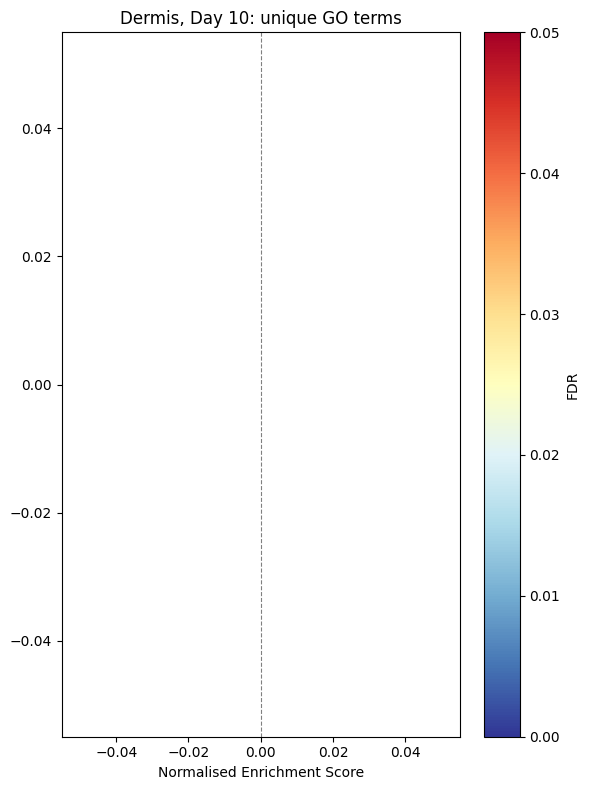

In [100]:
gsea_dotplot(different.head(20), title = "Dermis, Day 10: unique GO terms")